In [24]:
import os
import vr2p
import zarr
import math
import pickle
import warnings
import vr2p.signal
import numpy as np
import pandas as pd
import colorcet as cc
import seaborn as sns
from tqdm import tqdm
from vr2p import styles
from scipy import stats
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt 
from scipy.stats import rankdata
from matplotlib import cm, colors
mpl.rcParams['pdf.fonttype'] = 42
from scipy.stats import spearmanr
from scipy.stats import mannwhitneyu
from ipyfilechooser import FileChooser
from skimage.measure import regionprops
from sklearn.impute import SimpleImputer
from linear2ac.io import get_main_data_folder
from matplotlib.colors import ListedColormap
from scipy.stats import pearsonr
from sklearn.manifold import TSNE
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from sklearn.decomposition import NMF
from sklearn.preprocessing import SplineTransformer, StandardScaler
from sklearn.manifold import MDS
from scipy.stats import linregress
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr
from scipy.stats import wilcoxon
from scipy.stats import sem, kruskal
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.stats import mode
from sklearn.naive_bayes import GaussianNB
from scipy.ndimage import zoom
from scipy.ndimage import generic_filter
from sklearn.manifold import MDS
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import t as t_dist

In [ ]:
def load_animal_spatial_data_trial_by_trial(animal_name, base_path="/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Set A", bin_size=5, min_speed=5, track_size=230):

    data = vr2p.ExperimentData(f"{base_path}/{animal_name}-SetA.zarr/")
    edges = np.arange(0, track_size + bin_size, bin_size)
    n_bins = len(edges) - 1

    results = {"fields": [], "speed": [], "trial_types": [], "trial_numbers": [], "day_ind": []}

    for s, vr in enumerate(data.vr):
        print(f"On Session {s}")

        trial = vr.trial.copy()
        pos = vr.path.frame.copy().reset_index().merge(trial[["trial_number", "reward_id"]], on="trial_number")
        pos["speed"] = pos.vr2p.rolling_speed(window_size=100, ignore_threshold=7.5)

        F = data.signals.multi_session.Fdemix[int(s)][:]
        F = F - F.min(axis=1, keepdims=True)
        dff, _ = vr2p.signal.df_over_f0(F, "maximin", subtract_min=True, sigma_baseline=20, window_size=200)

        p = pos.loc[pos.speed >= min_speed, ["frame", "position", "trial_number", "reward_id", "speed"]].copy()

        valid = [t for t in trial.trial_number.values if len(p[p.trial_number == t]) and np.nanmax(p[p.trial_number == t].position) >= 226]

        if not valid:
            continue

        p = p[p.trial_number.isin(valid)].copy()
        p["trial_idx"] = p.trial_number.map({t: i for i, t in enumerate(valid)})
        p["bin"] = pd.cut(p.position, edges, include_lowest=True, labels=False)
        p = p.dropna(subset=["bin"]).copy()
        p["bin"] = p["bin"].astype(int)
        p = p[p.bin >= 0]

        mat = np.full((len(valid), F.shape[0], n_bins), np.nan)
        speed = np.full((len(valid), n_bins), np.nan)

        for (ti, bi), g in p.groupby(["trial_idx", "bin"]):
            frames = g.frame.to_numpy()
            mat[ti, :, bi] = dff[:, frames].mean(axis=1)
            speed[ti, bi] = g.speed.mean()

        results["fields"].append(mat)  # n_trials x n_cells x n_bins
        results["speed"].append(speed) # n_trials x n_bins
        results["trial_types"].append(trial.set_index("trial_number").loc[valid, "reward_id"].to_numpy())
        results["trial_numbers"].append(np.asarray(valid))
        results["day_ind"].append(s)

    return results

def load_animal_continuous_data(
        animal_name, 
        session, 
        base_path="/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Set A", 
        min_speed=0, 
        track_size=230):
    data = vr2p.ExperimentData(f"{base_path}/{animal_name}-SetA.zarr/")

    vr = data.vr[session]
    print(f"On Session {session}")

    # behavior
    trial = vr.trial.copy()

    pos = (vr.path.frame.copy().reset_index().merge(trial[["trial_number", "reward_id"]], on="trial_number"))
    pos["speed"] = pos.vr2p.rolling_speed(window_size=100, ignore_threshold=7.5)

    # neural data
    #F = data.signals.multi_session.Fdemix[int(session)][:]
    #F = F - F.min(axis=1, keepdims=True)

    #dff, _ = vr2p.signal.df_over_f0(F, "maximin", subtract_min=True, sigma_baseline=20, window_size=200)

    # deconvolved traces
    F_dcs = data.signals.multi_session.spks[int(session)][:]

    n_neurons, T = F_dcs.shape

    # valid frames
    p = pos.loc[pos.speed >= min_speed, ["frame", "position", "trial_number", "reward_id", "speed"]].copy()

    valid_trials = [t for t in trial.trial_number.values if len(p[p.trial_number == t]) and np.nanmax(p[p.trial_number == t].position) >= track_size - 4]

    if not valid_trials:
        return None

    p = p[p.trial_number.isin(valid_trials)].copy()
    p = p[(p.frame >= 0) & (p.frame < T)].copy()

    if len(p) == 0:
        return None

    # time from trial onset
    p["time_from_trial_onset"] = (p.groupby("trial_number")["frame"].transform(lambda x: x - x.min()))

    frames = p["frame"].to_numpy().astype(int)

    # lick data
    lick = vr.lick.copy()
    lick = lick[(lick.frame >= 0) & (lick.frame < T) & (lick.period == "TASK")]

    lick_frames = lick["frame"].to_numpy().astype(int)

    lick_binary_full = np.zeros(T)
    lick_binary_full[lick_frames] = 1

    lick_count_full = np.zeros(T)
    np.add.at(lick_count_full, lick_frames, 1)

    # -------- final output (no lists) --------
    results = {
        #"F": F[:, frames],
        #"dff": dff[:, frames],
        "F_dcs": F_dcs[:, frames],
        "position": p["position"].to_numpy(),
        "speed": p["speed"].to_numpy(),
        "time_from_trial_onset": p["time_from_trial_onset"].to_numpy(),
        "trial_type": p["reward_id"].to_numpy(),
        "trial_number": p["trial_number"].to_numpy(),
        "frame": frames,
        "day_ind": np.full(len(frames), session),
        "lick_binary": lick_binary_full[frames],
        "lick_count": lick_count_full[frames]}

    return results

def fill_nan_local_mean(mat, size=3):

    def nanmean_filter(x):
        x = x[np.isfinite(x)]
        return np.mean(x) if len(x) else np.nan

    mask = np.isnan(mat)
    filled = generic_filter(mat, nanmean_filter, size=size, mode="nearest")

    out = mat.copy()
    out[mask] = filled[mask]

    return out

def load_animal_spatial_data_session_by_session(animal, criteria="putative",
    base_setA="/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Set A",
    base_pf="/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/placeFields"):
    
    # --- load experiment data ---
    path = f"{base_setA}/{animal}-SetA.zarr/"
    data = vr2p.ExperimentData(path)

    # --- find consecutive days with Cue Set A only ---
    day_count = []
    for i in range(len(data.signals.multi_session.F)):
        sets = data.vr[i].trial.set.unique()
        if ("Cue Set A" in sets) and (len(sets) == 1):
            day_count.append(i)
        else:
            break

    max_day = int(max(day_count))  # last valid day index
    range_A = range(max_day + 1)

    # --- open PF zarr ---
    zarr_path = f"{base_pf}/{animal}-SetA.zarr-PF.zarr"
    zf = zarr.open(zarr_path, mode="r")

    # --- load PF analysis per day ---
    pf_all_T1 = [zf[f"Cue Set A/1/excl_no_response/{i}/{criteria}"][()] for i in range_A]
    pf_all_T2 = [zf[f"Cue Set A/2/excl_no_response/{i}/{criteria}"][()] for i in range_A]

    # --- load binned tuning curves per day ---
    binF_T1 = [pf_all_T1[i]["binF"] for i in range(len(pf_all_T1))]
    binF_T2 = [pf_all_T2[i]["binF"] for i in range(len(pf_all_T2))]

    binF_T1_all = np.array(binF_T1).T  # (N_cells, N_bins, N_sessions) depending on binF shape
    binF_T2_all = np.array(binF_T2).T

    return {
        "animal": animal,
        "path": path,
        "max_day": max_day,
        "range_A": range_A,
        "pf_all_T1": pf_all_T1,
        "pf_all_T2": pf_all_T2,
        "binF_T1_all": binF_T1_all,
        "binF_T2_all": binF_T2_all,
    }

def safe_nanmean(a, axis):
    count = np.sum(~np.isnan(a), axis=axis)
    total = np.nansum(a, axis=axis)

    out = np.full(total.shape, np.nan)
    mask = count > 0
    out[mask] = total[mask] / count[mask]

    return out

def build_trial_bin_population_matrix(
        PF,
        trial_types,
        trial_numbers,
        input_bin_size=5,
        output_bin_size=10,
        trial_block_size=3):
    """
    PF: n_trials x n_cells x n_bins

    trial_block_size:
        number of trials to average together.
        Trials are blocked separately within each trial type.

    returns:
        X:    (n_trial_blocks * n_output_bins) x n_cells
        meta: dataframe
    """

    n_trials, n_cells, n_bins_in = PF.shape

    trial_types = np.asarray(trial_types)
    trial_numbers = np.asarray(trial_numbers)

    if output_bin_size % input_bin_size != 0:
        raise ValueError("output_bin_size must be multiple of input_bin_size")

    combine = int(output_bin_size / input_bin_size)

    if n_bins_in % combine != 0:
        raise ValueError("n_bins not divisible by combine factor")

    if trial_block_size < 1:
        raise ValueError("trial_block_size must be >= 1")

    n_bins_out = n_bins_in // combine

    # spatial binning: trials x cells x output_bins
    PF_out = PF.reshape(n_trials, n_cells, n_bins_out, combine)
    PF_out = safe_nanmean(PF_out, axis=3)

    X_list = []
    meta = []

    block_counter = 0

    # block trials separately for each trial type
    for tt in np.unique(trial_types):

        trial_idx = np.where(trial_types == tt)[0]

        # keep original trial order
        trial_idx = trial_idx[np.argsort(trial_numbers[trial_idx])]

        for start in range(0, len(trial_idx), trial_block_size):

            block_trial_idx = trial_idx[start:start + trial_block_size]

            # average PF across trials within this block
            # shape: cells x bins
            PF_block = safe_nanmean(PF_out[block_trial_idx], axis=0)

            for b in range(n_bins_out):

                pop_vec = PF_block[:, b]

                X_list.append(pop_vec)

                meta.append({
                    "block_index": block_counter,
                    "trial_type": tt,
                    "trial_indices": block_trial_idx.tolist(),
                    "trial_numbers": trial_numbers[block_trial_idx].tolist(),
                    "block_start_trial": trial_numbers[block_trial_idx[0]],
                    "block_end_trial": trial_numbers[block_trial_idx[-1]],
                    "n_trials_in_block": len(block_trial_idx),
                    "bin": b,
                    "bin_start_cm": b * output_bin_size,
                    "bin_end_cm": (b + 1) * output_bin_size})

            block_counter += 1

    X = np.asarray(X_list)
    meta = pd.DataFrame(meta)

    return X, meta

def plot_embedding_3d_grid(
    embedding,
    Y,
    title="Embedding",
    n_plot=50000,
    position_range=None,
    normalize_embedding=True,
    marker_size=2.8,
    opacity=0.75,
):
    """
    2 x 3 interactive 3D grid.

    Row 1: trial type 1
        colored by scaled trial number, session, position

    Row 2: trial type 2
        colored by scaled trial number, session, position

    Y columns:
        0 = trial_type
        1 = trial_number
        2 = day_ind/session
        3 = position
        4 = spatial_bin
    """

    Z = np.asarray(embedding)
    Y = np.asarray(Y)

    # -------------------------------
    # base mask
    # -------------------------------

    mask = np.ones(len(Y), dtype=bool)

    sessions = np.sort(np.unique(Y[:, 2]))
    keep_sessions = sessions[:]
    mask &= np.isin(Y[:, 2], keep_sessions)

    # keep position range
    if position_range is not None:
        pmin, pmax = position_range
        mask &= (Y[:, 3] > pmin) & (Y[:, 3] < pmax)

    Z = Z[mask]
    Y = Y[mask]

    # -------------------------------
    # subsample
    # -------------------------------

    if len(Z) > n_plot:
        idx = np.random.choice(len(Z), size=n_plot, replace=False)
        Z = Z[idx]
        Y = Y[idx]

    # -------------------------------
    # normalize embedding
    # -------------------------------

    if normalize_embedding:
        Z = (Z - Z.mean(axis=0)) / (Z.std(axis=0) + 1e-8)

    # -------------------------------
    # scaled trial number
    # within session x trial type
    # -------------------------------

    trial_scaled = np.full(len(Y), np.nan)

    for sess in np.unique(Y[:, 2]):
        for tt in np.unique(Y[:, 0]):

            m = (Y[:, 2] == sess) & (Y[:, 0] == tt)

            if np.sum(m) == 0:
                continue

            vals = Y[m, 1]

            trial_scaled[m] = (
                vals - vals.min()
            ) / (
                vals.max() - vals.min() + 1e-8
            )

    # -------------------------------
    # masks for trial types
    # -------------------------------

    mask_t1 = Y[:, 0] == 1
    mask_t2 = Y[:, 0] == 2

    # -------------------------------
    # figure
    # -------------------------------

    titles = [
        "T1: scaled trial number",
        "T1: session",
        "T1: position",
        "T2: scaled trial number",
        "T2: session",
        "T2: position",
    ]

    fig = make_subplots(
        rows=2,
        cols=3,
        specs=[
            [{"type": "scene"}, {"type": "scene"}, {"type": "scene"}],
            [{"type": "scene"}, {"type": "scene"}, {"type": "scene"}],
        ],
        subplot_titles=titles,
        horizontal_spacing=0.02,
        vertical_spacing=0.05,
    )

    def add_panel(mask_panel, color_values, row, col, colorscale, color_title):

        fig.add_trace(
            go.Scatter3d(
                x=Z[mask_panel, 0],
                y=Z[mask_panel, 1],
                z=Z[mask_panel, 2],
                mode="markers",
                marker=dict(
                    size=marker_size,
                    color=color_values[mask_panel],
                    colorscale=colorscale,
                    opacity=opacity,
                    colorbar=dict(
                        title=color_title,
                        len=0.32,
                    ),
                ),
                customdata=np.column_stack([
                    Y[mask_panel, 0],
                    Y[mask_panel, 1],
                    Y[mask_panel, 2],
                    Y[mask_panel, 3],
                    Y[mask_panel, 4],
                ]),
                hovertemplate=(
                    "trial type=%{customdata[0]}<br>"
                    "trial=%{customdata[1]}<br>"
                    "session=%{customdata[2]}<br>"
                    "position=%{customdata[3]:.1f} cm<br>"
                    "bin=%{customdata[4]}<br>"
                    "<extra></extra>"
                ),
                showlegend=False,
            ),
            row=row,
            col=col,
        )

    # -------------------------------
    # row 1: trial type 1
    # -------------------------------

    add_panel(mask_t1, trial_scaled, 1, 1, "Jet", "trial")
    add_panel(mask_t1, Y[:, 2],       1, 2, "Viridis", "session")
    add_panel(mask_t1, Y[:, 3],       1, 3, "HSV", "position")

    # -------------------------------
    # row 2: trial type 2
    # -------------------------------

    add_panel(mask_t2, trial_scaled, 2, 1, "Jet", "trial")
    add_panel(mask_t2, Y[:, 2],       2, 2, "Viridis", "session")
    add_panel(mask_t2, Y[:, 3],       2, 3, "HSV", "position")

    # -------------------------------
    # layout
    # -------------------------------

    fig.update_layout(
        width=1600,
        height=900,
        title=title,
        margin=dict(l=0, r=0, b=0, t=50),
    )

    fig.show()
    
def build_trial_bin_PV_single_trials(
    PF,
    trial_types,
    trial_numbers,
    session,
    bin_size=5):
    """
    PF: trials x cells x bins

    Returns:
        X:    (trials * bins) x cells
        meta: dataframe with trial/bin/session info
    """

    PF = np.asarray(PF, float)
    trial_types = np.asarray(trial_types)
    trial_numbers = np.asarray(trial_numbers)

    n_trials, n_cells, n_bins = PF.shape

    X_list = []
    meta = []

    for tr in range(n_trials):
        for b in range(n_bins):

            X_list.append(PF[tr, :, b])

            meta.append({
                "session": session,
                "trial_index": tr,
                "trial_number": trial_numbers[tr],
                "trial_type": trial_types[tr],
                "bin": b,
                "bin_1based": b + 1,
                "bin_start_cm": b * bin_size,
                "bin_end_cm": (b + 1) * bin_size})

    return np.asarray(X_list), pd.DataFrame(meta)

def corr_template_blocks_fast(
    animal_data,
    trial_type=1,
    block_size=5,
    template_cm=(130,150),
    template_session=0,
    template_block=0,
    bin_size=5
):

    blocks = []

    for s, (PF, TT) in enumerate(zip(animal_data["fields"], animal_data["trial_types"])):

        TT = np.asarray(TT)
        PF = PF[TT == trial_type]

        for b in range(len(PF) // block_size):

            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=RuntimeWarning)

                PF_block = np.nanmean(
                    PF[b*block_size:(b+1)*block_size],
                    axis=0
                )  # cells x bins

            blocks.append((s, b, PF_block))

    if len(blocks) < 2:
        return None

    template_bins = (
        int(template_cm[0] / bin_size),
        int(template_cm[1] / bin_size)
    )

    template_block_data = [
        blk for s, b, blk in blocks
        if s == template_session and b == template_block
    ]

    if len(template_block_data) == 0:
        return None

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)

        template = np.nanmean(
            template_block_data[0][:, template_bins[0]:template_bins[1]],
            axis=1
        )

    mat, meta = [], []

    for s, b, PF in blocks:

        r = np.full(PF.shape[1], np.nan)

        for xbin in range(PF.shape[1]):

            y = PF[:, xbin]

            m = np.isfinite(template) & np.isfinite(y)

            if (
                m.sum() > 5
                and np.std(template[m]) > 0
                and np.std(y[m]) > 0
            ):
                r[xbin] = np.corrcoef(template[m], y[m])[0, 1]

        mat.append(r)
        meta.append((s, b))

    return np.asarray(mat), meta

def detect_pf_emergence_norm01_v2(
    PFs,
    bin_size=5,
    active_thresh=0.15,
    min_consecutive_on=5,
    min_consecutive_off=4,
    in_out_ratio_thresh=2.0,
    field_radius_bins=4,
    field_activity_radius_bins=6,
    eps=1e-9,
):
    """
    PFs: trials x cells x bins

    Logic:
    1. Normalize each cell's full trial x bin matrix to [0, 1].
    2. Detect mean place-field peak.
    3. Use peak +/- field_activity_radius_bins to define the field window.
    4. A trial is active only if activity inside this field window > active_thresh.
    5. Find all active epochs.
    6. Keep the longest active epoch.
    """

    n_trials, n_cells, n_bins = PFs.shape

    emergence_trial = np.full(n_cells, np.nan)
    turnoff_trial = np.full(n_cells, np.nan)
    peak_bin = np.full(n_cells, np.nan)
    peak_cm = np.full(n_cells, np.nan)
    valid_field = np.zeros(n_cells, dtype=bool)

    PFs_norm = np.full_like(PFs, np.nan, dtype=float)

    for cell in range(n_cells):

        mat = np.asarray(PFs[:, cell, :], float)

        if np.all(~np.isfinite(mat)):
            continue

        mn = np.nanmin(mat)
        mx = np.nanmax(mat)

        if not np.isfinite(mn) or not np.isfinite(mx) or (mx - mn) < eps:
            continue

        mat_norm = (mat - mn) / (mx - mn)
        PFs_norm[:, cell, :] = mat_norm

        # ----------------------------------------------------
        # mean PF and peak detection
        # ----------------------------------------------------

        mean_curve = np.nanmean(mat_norm, axis=0)

        if np.all(~np.isfinite(mean_curve)):
            continue

        pk = int(np.nanargmax(mean_curve))

        # window for in/out place-field ratio
        left_ratio = max(0, pk - field_radius_bins)
        right_ratio = min(n_bins - 1, pk + field_radius_bins)

        in_field = mean_curve[left_ratio:right_ratio + 1]
        out_field = np.concatenate([mean_curve[:left_ratio], mean_curve[right_ratio + 1:]])

        in_mean = np.nanmean(in_field)
        out_mean = np.nanmean(out_field)

        if not np.isfinite(in_mean):
            continue

        if not np.isfinite(out_mean) or out_mean <= 0:
            continue

        if (in_mean / out_mean) < in_out_ratio_thresh:
            continue

        # window used for emergence / turnoff detection

        left_act = max(0, pk - field_activity_radius_bins)
        right_act = min(n_bins - 1, pk + field_activity_radius_bins)
        field_activity = np.nanmax(mat_norm[:, left_act:right_act + 1], axis=1)

        high = field_activity > active_thresh

        # find all active epochs with turnoff tolerance
        epochs = []
        t = 0

        while t < n_trials:

            # find start of active run
            if not high[t]:
                t += 1
                continue

            start = t

            # require min_consecutive_on active trials at the beginning
            count_on = 0
            while t < n_trials and high[t]:
                count_on += 1
                t += 1

                if count_on >= min_consecutive_on:
                    break

            if count_on < min_consecutive_on:
                continue

            # true emergence is first trial of this active segment
            epoch_start = start

            # now continue until min_consecutive_off inactive trials
            off_count = 0
            last_active = t - 1

            while t < n_trials:

                if high[t]:
                    off_count = 0
                    last_active = t
                else:
                    off_count += 1

                if off_count >= min_consecutive_off:
                    break

                t += 1

            epoch_end = last_active

            epochs.append((epoch_start, epoch_end))

            t += 1

        if len(epochs) == 0:
            continue

        # ----------------------------------------------------
        # keep the longest active epoch
        # ----------------------------------------------------

        lengths = np.array([end - start + 1 for start, end in epochs])

        best_idx = int(np.argmax(lengths))
        best_start, best_end = epochs[best_idx]

        emergence_trial[cell] = best_start
        turnoff_trial[cell] = best_end
        peak_bin[cell] = pk
        peak_cm[cell] = pk * bin_size
        valid_field[cell] = True

    return (
        emergence_trial,
        turnoff_trial,
        peak_bin,
        peak_cm,
        valid_field,
        PFs_norm)

def pca_linearity(x, y, eps=1e-9):
    X = np.column_stack([x, y])
    X = X[np.isfinite(X).all(axis=1)]

    if len(X) < 3:
        return np.nan

    sx, sy = X[:,0].std(), X[:,1].std()

    if sx < eps and sy < eps:
        return np.nan

    if sx < eps or sy < eps:
        return 1.0   # vertical or horizontal line

    X = (X - X.mean(axis=0)) / X.std(axis=0)

    vals = np.linalg.eigvalsh(np.cov(X.T))
    vals = np.sort(vals)[::-1]

    return vals[0] / vals.sum()

def slope_linearity_pval(x, y, n_perm=1000, seed=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]

    if len(x) < 3:
        return np.nan, np.nan, np.nan

    slope = np.inf if np.allclose(np.var(x), 0) else np.polyfit(x, y, 1)[0]

    lin = pca_linearity(x, y)

    if not np.isfinite(lin):
        return slope, lin, np.nan

    rng = np.random.default_rng(seed)
    null_scores = np.array([pca_linearity(x, rng.permutation(y)) for _ in range(n_perm)])
    null_scores = null_scores[np.isfinite(null_scores)]

    if len(null_scores) == 0:
        return slope, lin, np.nan

    p_val = (1 + np.sum(null_scores >= lin)) / (len(null_scores) + 1)

    return slope, lin, p_val

def compute_monotonicity(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 2:
        return np.nan, np.nan

    dx = np.diff(x)
    dx = dx[np.isfinite(dx)]
    dx = dx[dx != 0]

    if len(dx) == 0:
        return np.nan, np.nan

    frac_forward = np.mean(dx > 0)
    frac_backward = np.mean(dx < 0)
    return frac_forward, frac_backward

def circular_diff(x2, x1, L=230.0):
    return (x2 - x1 + L/2) % L - L/2

def circular_unwrap_cm(pos_cm, track_length=230.0):
    pos_cm = np.asarray(pos_cm, dtype=float)

    if pos_cm.ndim != 1:
        raise ValueError("pos_cm must be 1D")
    if len(pos_cm) == 0:
        return pos_cm.copy()

    unwrapped = np.empty_like(pos_cm)
    unwrapped[0] = pos_cm[0]

    for i in range(1, len(pos_cm)):
        unwrapped[i] = unwrapped[i-1] + circular_diff(pos_cm[i], pos_cm[i-1], L=track_length)

    return unwrapped

def get_engaged_trials(PF, z_threshold=-2):
    """Return engaged-trial mask based on trial-by-trial population similarity."""
    n_trials = PF.shape[0]

    X = np.nan_to_num(PF.reshape(n_trials, -1))
    R = np.corrcoef(X)
    np.fill_diagonal(R, np.nan)

    trial_score = np.nanmean(R, axis=1)
    med = np.nanmedian(trial_score)
    mad = np.nanmedian(np.abs(trial_score - med))

    if mad == 0 or not np.isfinite(mad):
        return np.ones(n_trials, dtype=bool)

    robust_z = 0.6745 * (trial_score - med) / mad
    return robust_z > z_threshold

def classify_shift(slope, linearity, pval, mono_fw, mono_bw, SLOPE_THRESH, P_THRESH, MONO_THRESH):

    """Classify cell based on slope, p-value, and monotonicity."""
    if not np.all(np.isfinite([slope, linearity, pval])):
        return "invalid_fit"

    if pval <= P_THRESH and slope > SLOPE_THRESH and mono_fw >= MONO_THRESH:
        return "forward"

    if pval <= P_THRESH and slope < -SLOPE_THRESH and mono_bw >= MONO_THRESH:
        return "backward"

    if pval <= P_THRESH and abs(slope) <= SLOPE_THRESH:
        return "stable"

    return "neither"

def empty_row(animal, sess, trial_type, cell, n_orig, n_engaged, n_removed):
    """Default row for each cell."""
    return dict(
        animal=animal,
        session=sess,
        trial_type=trial_type,
        cell=cell,
        n_trials_original=n_orig,
        n_trials_engaged=n_engaged,
        n_removed_trials=n_removed,
        is_valid_pc=False,
        emergence_trial_engaged=np.nan,
        turnoff_trial_engaged=np.nan,
        emergence_trial_original=np.nan,
        turnoff_trial_original=np.nan,
        peak_bin=np.nan,
        peak_cm=np.nan,
        slope=np.nan,
        linearity=np.nan,
        pval=np.nan,
        mono_fw=np.nan,
        mono_bw=np.nan,
        label="not_pc"
    )

def get_PF_engaged(
    PF,
    z_threshold=-2,
    return_info=False
):
    """
    Remove disengaged trials using population similarity.

    Parameters
    ----------
    PF : array
        trials x cells x bins

    z_threshold : float
        robust-z threshold for engaged trials

    return_info : bool
        if True, also return diagnostics

    Returns
    -------
    PF_engaged : array
        engaged trials only

    Optional additional outputs if return_info=True:
    ------------------------------------------------
    engaged : bool array
    robust_z : array
    trial_score : array
    """

    PF = np.asarray(PF, float)

    n_trials = PF.shape[0]

    # --------------------------------------------------------
    # flatten population vectors
    # --------------------------------------------------------

    X = PF.reshape(n_trials, -1)
    X = np.nan_to_num(X)

    # --------------------------------------------------------
    # trial similarity matrix
    # --------------------------------------------------------

    RSM = np.corrcoef(X)

    R = RSM.copy()
    np.fill_diagonal(R, np.nan)

    # mean similarity of each trial to all others
    trial_score = np.nanmean(R, axis=1)

    # --------------------------------------------------------
    # robust z-score
    # --------------------------------------------------------

    med = np.nanmedian(trial_score)
    mad = np.nanmedian(np.abs(trial_score - med))

    if mad == 0 or not np.isfinite(mad):

        engaged = np.ones(n_trials, dtype=bool)
        robust_z = np.full(n_trials, np.nan)

    else:

        robust_z = 0.6745 * (trial_score - med) / mad
        engaged = robust_z > z_threshold

    PF_engaged = PF[engaged]

    # --------------------------------------------------------
    # return
    # --------------------------------------------------------

    if return_info:

        return (
            PF_engaged,
            engaged,
            robust_z,
            trial_score
        )

    return PF_engaged


In [ ]:
animals = ['Tyche-A4', 'Tyche-A5', 'Tyche-A7', 'Tyche-B2', 'Tyche-B3', 'Tyche-B4', 'Tyche-B5']

In [ ]:
with open("Data_trial.pkl", "rb") as f:
    Data_trial = pickle.load(f)

In [36]:
# Parameters
MONO_THRESH  = 0.0
SLOPE_THRESH = .5
P_THRESH     = 0.05
bin_size     = 5
z_threshold  = -2
track_length = 230


rows = []
for animal in animals:

    data = Data_trial[animal]
    n_sessions = len(data["fields"])

    for sess in range(n_sessions):
        for trial_type in [1, 2]:

            print(f"Analyzing {animal}, session {sess}, trial type {trial_type}")

            PF_all = np.asarray(data["fields"][sess], float)
            tt = np.asarray(data["trial_types"][sess])

            trial_idx = np.where(tt == trial_type)[0]
            PF = PF_all[trial_idx]

            n_orig = PF.shape[0]
            if n_orig < 5:
                continue

            engaged = get_engaged_trials(PF, z_threshold=z_threshold)
            PF_engaged = PF[engaged]
            engaged_trial_numbers = trial_idx[engaged]

            n_engaged = PF_engaged.shape[0]
            n_removed = int(np.sum(~engaged))

            if n_engaged < 5:
                continue

            emergence, turnoff, peak_bin, peak_cm, valid_pc, PF_norm = detect_pf_emergence_norm01_v2(
                PF_engaged,
                bin_size=bin_size,
                active_thresh=0.08,
                min_consecutive_on=3,
                min_consecutive_off=4,
                in_out_ratio_thresh=1.5,
                field_radius_bins=4,
                field_activity_radius_bins=6)

            n_cells = PF_engaged.shape[1]

            for cell in range(n_cells):

                row = empty_row(animal, sess, trial_type, cell, n_orig, n_engaged, n_removed)

                row["is_valid_pc"] = bool(valid_pc[cell])

                if not valid_pc[cell]:
                    rows.append(row)
                    continue

                start = int(emergence[cell])
                end = int(turnoff[cell])

                row.update(
                    emergence_trial_engaged=start,
                    turnoff_trial_engaged=end,
                    emergence_trial_original=engaged_trial_numbers[start],
                    turnoff_trial_original=engaged_trial_numbers[end],
                    peak_bin=peak_bin[cell],
                    peak_cm=peak_cm[cell],
                    label="too_short")

                mat = PF_norm[start:end + 1, cell, :]

                if mat.shape[0] < 3:
                    rows.append(row)
                    continue

                trial_peak_bin = np.array([np.nanargmax(x) if np.any(np.isfinite(x)) else np.nan for x in mat])
                
                y = circular_unwrap_cm(trial_peak_bin * bin_size, track_length=track_length)
                x = np.arange(len(y))
                slope, linearity, pval = slope_linearity_pval(x, y, n_perm=100, seed=cell + sess * 10000 + trial_type * 100000)
                mono_fw, mono_bw = compute_monotonicity(y)

                row.update(
                    slope=slope,
                    linearity=linearity,
                    pval=pval,
                    mono_fw=mono_fw,
                    mono_bw=mono_bw,
                    label=classify_shift(slope, linearity, pval, mono_fw, mono_bw, SLOPE_THRESH, P_THRESH, MONO_THRESH))

                rows.append(row)

df_pf_dynamics = pd.DataFrame(rows)

Analyzing Tyche-A4, session 0, trial type 1
Analyzing Tyche-A4, session 0, trial type 2
Analyzing Tyche-A4, session 1, trial type 1
Analyzing Tyche-A4, session 1, trial type 2
Analyzing Tyche-A4, session 2, trial type 1
Analyzing Tyche-A4, session 2, trial type 2
Analyzing Tyche-A4, session 3, trial type 1
Analyzing Tyche-A4, session 3, trial type 2
Analyzing Tyche-A4, session 4, trial type 1
Analyzing Tyche-A4, session 4, trial type 2
Analyzing Tyche-A4, session 5, trial type 1
Analyzing Tyche-A4, session 5, trial type 2
Analyzing Tyche-A4, session 6, trial type 1
Analyzing Tyche-A4, session 6, trial type 2
Analyzing Tyche-A4, session 7, trial type 1
Analyzing Tyche-A4, session 7, trial type 2
Analyzing Tyche-A4, session 8, trial type 1
Analyzing Tyche-A4, session 8, trial type 2
Analyzing Tyche-A4, session 9, trial type 1
Analyzing Tyche-A4, session 9, trial type 2
Analyzing Tyche-A5, session 0, trial type 1
Analyzing Tyche-A5, session 0, trial type 2
Analyzing Tyche-A5, session 1, t

/tmp/ipykernel_13495/1824746234.py:640: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(mat_norm, axis=0)


Analyzing Tyche-B5, session 6, trial type 2


Saved: /home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/single_cell_dynamics_summary.pdf


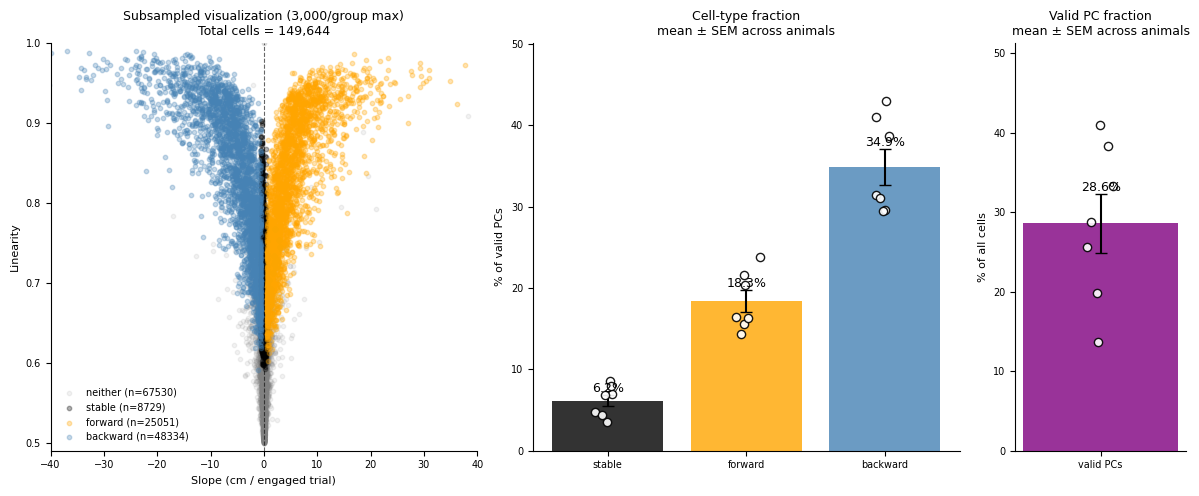

In [45]:
EPS = 1e-6

colors = {
    "backward": "steelblue",
    "stable": "black",
    "forward": "orange",
    "neither": "gray",
    "valid_pc": "purple"}

plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
})

plot_labels = ["neither", "stable", "forward", "backward"]
summary_labels = ["stable", "forward", "backward"]

# -------------------------
# Clean data
# -------------------------
df = df_pf_dynamics.copy()

d = df[df["is_valid_pc"]].copy()
d = d[np.isfinite(d["slope"]) & np.isfinite(d["linearity"])]
d["yplot"] = d["linearity"] + EPS

animals_use = sorted(df["animal"].dropna().unique())

# Animal-level summary:
# % of valid PCs that are stable/fw/bw
animal_summary = []

for animal in animals_use:
    da = d[d["animal"] == animal]
    n_valid = len(da)

    row = {"animal": animal, "n_valid": n_valid}

    for lab in summary_labels:
        row[lab] = 100 * np.mean(da["label"] == lab) if n_valid > 0 else np.nan

    animal_summary.append(row)

animal_summary = pd.DataFrame(animal_summary)

# Animal-level % valid PCs
# denominator = all cells/rows in df_pf_dynamics per animal
valid_summary = []

for animal in animals_use:
    da_all = df[df["animal"] == animal]
    n_all = len(da_all)
    n_valid = np.sum(da_all["is_valid_pc"])

    valid_summary.append({
        "animal": animal,
        "n_all": n_all,
        "n_valid": n_valid,
        "valid_pc_percent": 100 * n_valid / n_all if n_all > 0 else np.nan})

valid_summary = pd.DataFrame(valid_summary)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 1, .4]})

# -------------------------
# Scatter — rasterized for lightweight PDF
# -------------------------
# -------------------------
# Scatter — subsampled
# -------------------------
ax = axes[0]

N_PER_GROUP = 3000  # adjust as desired

rng = np.random.default_rng(0)

for lab in plot_labels:

    dd = d[d["label"] == lab]

    if len(dd) > N_PER_GROUP:
        idx = rng.choice(len(dd), N_PER_GROUP, replace=False)
        dd_plot = dd.iloc[idx]
    else:
        dd_plot = dd

    ax.scatter(
        dd_plot["slope"],
        dd_plot["yplot"],
        s=10,
        color=colors[lab],
        alpha=0.3 if lab != "neither" else 0.1,
        label=f"{lab} (n={len(dd)})")

ax.axvline(0, color="k", lw=0.8, ls="--", alpha=0.6)
ax.set_xlim([-40, 40])
ax.set_ylim([0.49, 1])
ax.set_xlabel("Slope (cm / engaged trial)")
ax.set_ylabel("Linearity")
ax.set_title(
    f"Subsampled visualization ({N_PER_GROUP:,}/group max)\n"
    f"Total cells = {len(d):,}"
)
ax.legend(frameon=False, fontsize=7)

# Bar plot: stable/fw/bw across animals
ax = axes[1]
x = np.arange(len(summary_labels))
means = animal_summary[summary_labels].mean(axis=0).values
sems = animal_summary[summary_labels].sem(axis=0).values
ax.bar(x, means, yerr=sems, color=[colors[g] for g in summary_labels], alpha=0.8, capsize=4)

# individual animals
for i, lab in enumerate(summary_labels):
    y = animal_summary[lab].values
    jitter = np.random.normal(0, 0.05, size=len(y))
    ax.scatter(np.full(len(y), i) + jitter, y, color="white", edgecolor="k", s=35, zorder=3, alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(summary_labels)
ax.set_ylabel("% of valid PCs")
ax.set_title("Cell-type fraction\nmean ± SEM across animals")

ymax = np.nanmax(means + sems) * 1.35
ax.set_ylim([0, ymax])

for i, v in enumerate(means):
    ax.text(i, v + sems[i], f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

# Bar plot: % valid PCs across animals
ax = axes[2]
valid_vals = valid_summary["valid_pc_percent"].values
valid_mean = np.nanmean(valid_vals)
valid_sem = pd.Series(valid_vals).sem()
ax.bar([0], [valid_mean], yerr=[valid_sem], color=colors["valid_pc"], alpha=0.8, capsize=4)
jitter = np.random.normal(0, 0.05, size=len(valid_vals))
ax.scatter(np.zeros(len(valid_vals)) + jitter, valid_vals, color="white", edgecolor="k", s=35, zorder=3, alpha=0.9)
ax.set_xticks([0])
ax.set_xticklabels(["valid PCs"])
ax.set_ylabel("% of all cells")
ax.set_title("Valid PC fraction\nmean ± SEM across animals")

ax.set_ylim([0, np.nanmax(valid_vals) * 1.25])
ax.text(0, valid_mean + valid_sem, f"{valid_mean:.1f}%", ha="center", va="bottom", fontsize=9)

# Style
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()

save_path = "/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/single_cell_dynamics_summary.pdf"

fig.savefig(
    save_path,
    format="pdf",
    bbox_inches="tight",
    dpi=300
)

print(f"Saved: {save_path}")

plt.show()

In [41]:
# -------------------------------------------------------
# Cross-session PF evolution classification
# -------------------------------------------------------

MONO_THRESH  = 0.0
SLOPE_THRESH = 5     # cm / session
P_THRESH     = 0.05
bin_size     = 5
z_threshold  = -2
track_length = 230
min_pc_sessions = 3

cross_rows = []

for animal in animals:

    data = Data_trial[animal]
    n_sessions = len(data["fields"])

    # animal -> trial_type -> cell -> session-level info
    cell_session_data = {
        1: {},
        2: {}
    }

    for sess in range(n_sessions):

        PF_all = np.asarray(data["fields"][sess], float)
        tt = np.asarray(data["trial_types"][sess])
        n_cells = PF_all.shape[1]

        for trial_type in [1, 2]:

            print(f"Within-session PC detection: {animal}, session {sess}, TT{trial_type}")

            trial_idx = np.where(tt == trial_type)[0]
            PF = PF_all[trial_idx]

            if PF.shape[0] < 5:
                continue

            engaged = get_engaged_trials(PF, z_threshold=z_threshold)
            PF_engaged = PF[engaged]

            if PF_engaged.shape[0] < 5:
                continue

            emergence, turnoff, peak_bin, peak_cm, valid_pc, PF_norm = detect_pf_emergence_norm01_v2(
                PF_engaged,
                bin_size=bin_size,
                active_thresh=0.08,
                min_consecutive_on=3,
                min_consecutive_off=4,
                in_out_ratio_thresh=1.5,
                field_radius_bins=4,
                field_activity_radius_bins=6
            )

            for cell in range(n_cells):

                if cell not in cell_session_data[trial_type]:
                    cell_session_data[trial_type][cell] = []

                if not valid_pc[cell]:
                    continue

                start = int(emergence[cell])
                end = int(turnoff[cell])

                if end <= start:
                    continue

                # average only during the valid active PF period
                mat = PF_norm[start:end + 1, cell, :]

                if mat.shape[0] < 3:
                    continue

                mean_pf = np.nanmean(mat, axis=0)

                if np.all(~np.isfinite(mean_pf)):
                    continue

                sess_peak_bin = np.nanargmax(mean_pf)
                sess_peak_cm = sess_peak_bin * bin_size

                cell_session_data[trial_type][cell].append({
                    "animal": animal,
                    "session": sess,
                    "trial_type": trial_type,
                    "cell": cell,
                    "mean_pf": mean_pf,
                    "peak_bin": sess_peak_bin,
                    "peak_cm": sess_peak_cm,
                    "emergence": start,
                    "turnoff": end
                })

    # -------------------------------------------------------
    # Cross-session classification
    # -------------------------------------------------------

    for trial_type in [1, 2]:

        for cell, sess_list in cell_session_data[trial_type].items():

            row = {
                "animal": animal,
                "trial_type": trial_type,
                "cell": cell,
                "n_pc_sessions": len(sess_list),
                "sessions": np.nan,
                "peak_cm_by_session": np.nan,
                "slope": np.nan,
                "linearity": np.nan,
                "pval": np.nan,
                "mono_fw": np.nan,
                "mono_bw": np.nan,
                "label": "too_few_pc_sessions"
            }

            if len(sess_list) < min_pc_sessions:
                cross_rows.append(row)
                continue

            sess_list = sorted(sess_list, key=lambda d: d["session"])

            sessions = np.array([d["session"] for d in sess_list], dtype=float)
            peak_cm = np.array([d["peak_cm"] for d in sess_list], dtype=float)

            # circular unwrap across sessions
            y = circular_unwrap_cm(
                peak_cm,
                track_length=track_length
            )

            # use true session numbers as x
            x = sessions.copy()

            slope, linearity, pval = slope_linearity_pval(
                x,
                y,
                n_perm=100,
                seed=cell + trial_type * 100000
            )

            mono_fw, mono_bw = compute_monotonicity(y)

            label = classify_shift(
                slope,
                linearity,
                pval,
                mono_fw,
                mono_bw,
                SLOPE_THRESH,
                P_THRESH,
                MONO_THRESH
            )

            row.update({
                "sessions": sessions,
                "peak_cm_by_session": peak_cm,
                "unwrapped_peak_cm_by_session": y,
                "slope": slope,
                "linearity": linearity,
                "pval": pval,
                "mono_fw": mono_fw,
                "mono_bw": mono_bw,
                "label": label
            })

            cross_rows.append(row)

df_pf_cross_session_dynamics = pd.DataFrame(cross_rows)

Within-session PC detection: Tyche-A4, session 0, TT1
Within-session PC detection: Tyche-A4, session 0, TT2
Within-session PC detection: Tyche-A4, session 1, TT1
Within-session PC detection: Tyche-A4, session 1, TT2
Within-session PC detection: Tyche-A4, session 2, TT1
Within-session PC detection: Tyche-A4, session 2, TT2
Within-session PC detection: Tyche-A4, session 3, TT1
Within-session PC detection: Tyche-A4, session 3, TT2
Within-session PC detection: Tyche-A4, session 4, TT1
Within-session PC detection: Tyche-A4, session 4, TT2
Within-session PC detection: Tyche-A4, session 5, TT1
Within-session PC detection: Tyche-A4, session 5, TT2
Within-session PC detection: Tyche-A4, session 6, TT1
Within-session PC detection: Tyche-A4, session 6, TT2
Within-session PC detection: Tyche-A4, session 7, TT1
Within-session PC detection: Tyche-A4, session 7, TT2
Within-session PC detection: Tyche-A4, session 8, TT1
Within-session PC detection: Tyche-A4, session 8, TT2
Within-session PC detection:

/tmp/ipykernel_13495/929796184.py:79: RuntimeWarning: Mean of empty slice
  mean_pf = np.nanmean(mat, axis=0)


Within-session PC detection: Tyche-B3, session 12, TT1
Within-session PC detection: Tyche-B3, session 12, TT2
Within-session PC detection: Tyche-B3, session 13, TT1
Within-session PC detection: Tyche-B3, session 13, TT2
Within-session PC detection: Tyche-B3, session 14, TT1
Within-session PC detection: Tyche-B3, session 14, TT2
Within-session PC detection: Tyche-B4, session 0, TT1
Within-session PC detection: Tyche-B4, session 0, TT2
Within-session PC detection: Tyche-B4, session 1, TT1
Within-session PC detection: Tyche-B4, session 1, TT2
Within-session PC detection: Tyche-B4, session 2, TT1
Within-session PC detection: Tyche-B4, session 2, TT2
Within-session PC detection: Tyche-B4, session 3, TT1
Within-session PC detection: Tyche-B4, session 3, TT2
Within-session PC detection: Tyche-B4, session 4, TT1
Within-session PC detection: Tyche-B4, session 4, TT2
Within-session PC detection: Tyche-B5, session 0, TT1
Within-session PC detection: Tyche-B5, session 0, TT2
Within-session PC dete

/tmp/ipykernel_13495/1824746234.py:640: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(mat_norm, axis=0)


Within-session PC detection: Tyche-B5, session 6, TT2


Saved: /home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/cross_session_single_cell_dynamics_summary.pdf


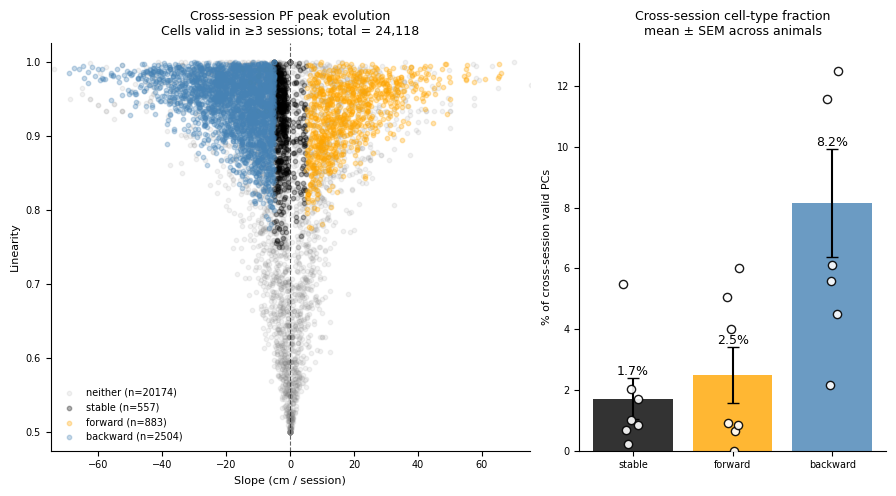

In [44]:
EPS = 1e-6

colors = {
    "backward": "steelblue",
    "stable": "black",
    "forward": "orange",
    "neither": "gray"
}

plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
})

plot_labels = ["neither", "stable", "forward", "backward"]
summary_labels = ["stable", "forward", "backward"]

# -------------------------
# Clean cross-session data
# -------------------------
df = df_pf_cross_session_dynamics.copy()

d = df[df["n_pc_sessions"] >= min_pc_sessions].copy()
d = d[np.isfinite(d["slope"]) & np.isfinite(d["linearity"])]
d["yplot"] = d["linearity"] + EPS

animals_use = sorted(df["animal"].dropna().unique())

# -------------------------
# Animal-level summary:
# % of cross-session valid PCs classified as stable/fw/bw
# denominator = cells valid PCs in >= min_pc_sessions
# -------------------------
animal_summary = []

for animal in animals_use:

    da = d[d["animal"] == animal]
    n_valid = len(da)

    row = {
        "animal": animal,
        "n_valid_cross_session_pc": n_valid
    }

    for lab in summary_labels:
        row[lab] = 100 * np.mean(da["label"] == lab) if n_valid > 0 else np.nan

    animal_summary.append(row)

animal_summary = pd.DataFrame(animal_summary)

# -------------------------
# Plot
# -------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(9, 5),
    gridspec_kw={"width_ratios": [1.25, 0.8]}
)

# -------------------------
# Panel 1: slope vs linearity
# -------------------------
ax = axes[0]

N_PER_GROUP = 3000
rng = np.random.default_rng(0)

for lab in plot_labels:

    dd = d[d["label"] == lab]

    if len(dd) > N_PER_GROUP:
        idx = rng.choice(len(dd), N_PER_GROUP, replace=False)
        dd_plot = dd.iloc[idx]
    else:
        dd_plot = dd

    ax.scatter(
        dd_plot["slope"],
        dd_plot["yplot"],
        s=10,
        color=colors[lab],
        alpha=0.3 if lab != "neither" else 0.1,
        label=f"{lab} (n={len(dd)})"
    )

ax.axvline(0, color="k", lw=0.8, ls="--", alpha=0.6)

ax.set_xlim([-75, 75])
#ax.set_ylim([0.49, 1.0])

ax.set_xlabel("Slope (cm / session)")
ax.set_ylabel("Linearity")
ax.set_title(
    f"Cross-session PF peak evolution\n"
    f"Cells valid in ≥{min_pc_sessions} sessions; total = {len(d):,}"
)

ax.legend(frameon=False, fontsize=7)

# -------------------------
# Panel 2: stable/fw/bw fraction across animals
# -------------------------
ax = axes[1]

x = np.arange(len(summary_labels))

means = animal_summary[summary_labels].mean(axis=0).values
sems = animal_summary[summary_labels].sem(axis=0).values

ax.bar(
    x,
    means,
    yerr=sems,
    color=[colors[g] for g in summary_labels],
    alpha=0.8,
    capsize=4
)

for i, lab in enumerate(summary_labels):

    y = animal_summary[lab].values
    jitter = np.random.normal(0, 0.05, size=len(y))

    ax.scatter(
        np.full(len(y), i) + jitter,
        y,
        color="white",
        edgecolor="k",
        s=35,
        zorder=3,
        alpha=0.9
    )

ax.set_xticks(x)
ax.set_xticklabels(summary_labels)
ax.set_ylabel("% of cross-session valid PCs")
ax.set_title("Cross-session cell-type fraction\nmean ± SEM across animals")

ymax = np.nanmax(means + sems) * 1.35
ax.set_ylim([0, ymax if np.isfinite(ymax) and ymax > 0 else 1])

for i, v in enumerate(means):
    ax.text(
        i,
        v + sems[i],
        f"{v:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

# -------------------------
# Style and save
# -------------------------
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()

save_path = (
    "/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/"
    "cross_session_single_cell_dynamics_summary.pdf"
)

fig.savefig(
    save_path,
    format="pdf",
    bbox_inches="tight",
    dpi=300
)

print(f"Saved: {save_path}")

plt.show()

In [54]:
groups = ["backward", "stable", "forward", "neither"]

within_from_cross = {}

for group in groups:

    rows_all = []

    d_cross = df_pf_cross_session_dynamics[
        df_pf_cross_session_dynamics["label"] == group
    ]

    for _, row in d_cross.iterrows():

        animal = row["animal"]
        trial_type = row["trial_type"]
        cell = row["cell"]

        sess_list = row["sessions"]

        d_within = df_pf_dynamics[
            (df_pf_dynamics["animal"] == animal) &
            (df_pf_dynamics["trial_type"] == trial_type) &
            (df_pf_dynamics["cell"] == cell) &
            (df_pf_dynamics["session"].isin(sess_list)) &
            (df_pf_dynamics["is_valid_pc"])
        ]

        rows_all.append(d_within)

    if len(rows_all):
        within_from_cross[group] = pd.concat(rows_all, ignore_index=True)
    else:
        within_from_cross[group] = pd.DataFrame()

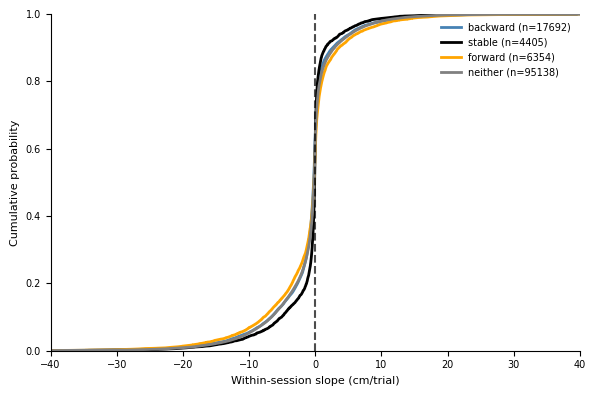

In [55]:
groups = ["backward", "stable", "forward", "neither"]

colors = {
    "backward": "steelblue",
    "stable": "black",
    "forward": "orange",
    "neither": "gray"
}

fig, ax = plt.subplots(figsize=(6,4))

for group in groups:

    vals = within_from_cross[group]["slope"].values
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        continue

    vals = np.sort(vals)
    cdf = np.arange(1, len(vals) + 1) / len(vals)

    ax.plot(
        vals,
        cdf,
        lw=2,
        color=colors[group],
        label=f"{group} (n={len(vals)})"
    )

ax.axvline(0, color="k", ls="--", alpha=0.7)

ax.set_xlabel("Within-session slope (cm/trial)")
ax.set_ylabel("Cumulative probability")
ax.set_xlim([-40, 40])
ax.set_ylim([0, 1])

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [59]:
groups = ["backward", "stable", "forward", "neither"]

summary = []

for group in groups:

    d = within_from_cross[group]

    slopes = d["slope"].values
    slopes = slopes[np.isfinite(slopes)]

    linearity = d["linearity"].values
    linearity = linearity[np.isfinite(linearity)]

    summary.append({
        "group": group,
        "slope_mean": np.nanmean(slopes),
        "slope_sem": scipy.stats.sem(slopes, nan_policy="omit"),
        "lin_mean": np.nanmean(linearity),
        "lin_sem": scipy.stats.sem(linearity, nan_policy="omit"),
        "n": len(slopes)
    })

summary = pd.DataFrame(summary)

backward vs stable: p=5.991e-15
backward vs forward: p=0.002562
backward vs neither: p=2.873e-08
stable vs forward: p=0.002927
stable vs neither: p=1.724e-06
forward vs neither: p=0.7749
Kruskal-Wallis: H=59.896, p=6.188e-13
Saved: /home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/within_session_slope_by_cross_session_cell_type_bar_cdf_stats.pdf


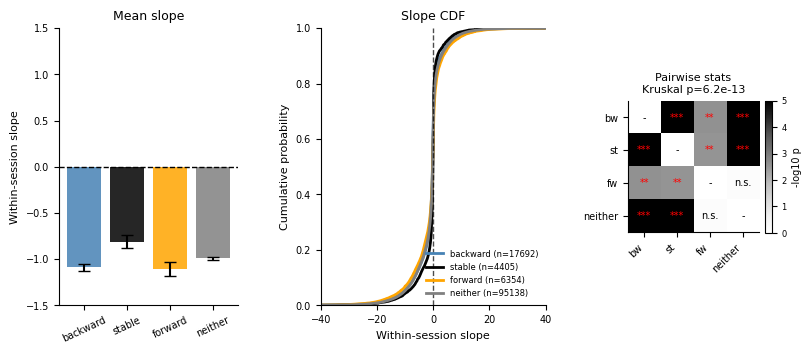

In [81]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations

# -------------------------------------------------------
# Parameters
# -------------------------------------------------------
save_dir = "/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(
    save_dir,
    "within_session_slope_by_cross_session_cell_type_bar_cdf_stats.pdf"
)

groups = ["backward", "stable", "forward", "neither"]

colors = {
    "backward": "steelblue",
    "stable": "black",
    "forward": "orange",
    "neither": "gray"
}

# -------------------------------------------------------
# Pooled slope data
# -------------------------------------------------------
plot_data = {}

for group in groups:

    vals = within_from_cross[group]["slope"].values
    vals = vals[np.isfinite(vals)]

    plot_data[group] = vals

# -------------------------------------------------------
# Stats
# -------------------------------------------------------
valid_groups = [g for g in groups if len(plot_data[g]) > 0]

stat, p_kruskal = kruskal(
    *[plot_data[g] for g in valid_groups]
)

pairwise_p = {}

for g1, g2 in combinations(groups, 2):

    if len(plot_data[g1]) == 0 or len(plot_data[g2]) == 0:
        p = np.nan
    else:
        _, p = mannwhitneyu(
            plot_data[g1],
            plot_data[g2],
            alternative="two-sided"
        )

    pairwise_p[(g1, g2)] = p
    print(f"{g1} vs {g2}: p={p:.4g}")

print(f"Kruskal-Wallis: H={stat:.3f}, p={p_kruskal:.4g}")


def p_to_star(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "n.s."


# -------------------------------------------------------
# Pairwise p-value matrix
# -------------------------------------------------------
p_mat = np.full((len(groups), len(groups)), np.nan)

for i, g1 in enumerate(groups):
    for j, g2 in enumerate(groups):

        if i == j:
            p_mat[i, j] = 1.0
        elif (g1, g2) in pairwise_p:
            p_mat[i, j] = pairwise_p[(g1, g2)]
        elif (g2, g1) in pairwise_p:
            p_mat[i, j] = pairwise_p[(g2, g1)]

with np.errstate(divide="ignore", invalid="ignore"):
    logp_mat = -np.log10(p_mat)

logp_mat[np.eye(len(groups), dtype=bool)] = 0
logp_mat[~np.isfinite(logp_mat)] = np.nan

# -------------------------------------------------------
# Bar summary
# -------------------------------------------------------
summary = []

for group in groups:

    vals = plot_data[group]

    summary.append({
        "group": group,
        "mean": np.nanmean(vals),
        "sem": pd.Series(vals).sem(),
        "n": len(vals)
    })

summary = pd.DataFrame(summary)

# -------------------------------------------------------
# Plot: bar + CDF + stats imshow
# -------------------------------------------------------
fig = plt.figure(figsize=(9.2, 3.6))

gs = fig.add_gridspec(
    1,
    3,
    width_ratios=[1.0, 1.25, 0.8],
    wspace=0.45
)

ax_bar = fig.add_subplot(gs[0, 0])
ax_cdf = fig.add_subplot(gs[0, 1])
ax_stat = fig.add_subplot(gs[0, 2])

# -------------------------
# Panel 1: bar plot
# -------------------------
for i, row in summary.iterrows():

    ax_bar.bar(
        i,
        row["mean"],
        yerr=row["sem"],
        color=colors[row["group"]],
        capsize=4,
        alpha=0.85
    )

ax_bar.axhline(0, color="k", ls="--", lw=1)

ax_bar.set_ylabel("Within-session slope")
ax_bar.set_xticks(range(len(summary)))
ax_bar.set_xticklabels(summary["group"], rotation=25)
ax_bar.set_title("Mean slope")
ax_bar.set_ylim([-1.5, 1.5])

for spine in ["top", "right"]:
    ax_bar.spines[spine].set_visible(False)

# -------------------------
# Panel 2: CDF
# -------------------------
for group in groups:

    vals = plot_data[group]

    if len(vals) == 0:
        continue

    vals_sorted = np.sort(vals)
    cdf = np.arange(1, len(vals_sorted) + 1) / len(vals_sorted)

    ax_cdf.plot(
        vals_sorted,
        cdf,
        lw=2,
        color=colors[group],
        label=f"{group} (n={len(vals_sorted)})"
    )

ax_cdf.axvline(0, color="k", ls="--", lw=1, alpha=0.7)

ax_cdf.set_xlabel("Within-session slope")
ax_cdf.set_ylabel("Cumulative probability")
ax_cdf.set_xlim([-40, 40])
ax_cdf.set_ylim([0, 1])
ax_cdf.set_title("Slope CDF")
ax_cdf.legend(frameon=False, fontsize=6)

for spine in ["top", "right"]:
    ax_cdf.spines[spine].set_visible(False)

# -------------------------
# Panel 3: stats matrix
# -------------------------
im = ax_stat.imshow(
    logp_mat,
    cmap="Greys",
    vmin=0,
    vmax=5
)

short_labels = ["bw", "st", "fw", "neither"]

ax_stat.set_xticks(np.arange(len(groups)))
ax_stat.set_yticks(np.arange(len(groups)))

ax_stat.set_xticklabels(
    short_labels,
    rotation=45,
    ha="right",
    fontsize=7
)

ax_stat.set_yticklabels(
    short_labels,
    fontsize=7
)

for i in range(len(groups)):
    for j in range(len(groups)):

        if i == j:
            txt = "-"
        else:
            txt = p_to_star(p_mat[i, j])

        ax_stat.text(
            j,
            i,
            txt,
            ha="center",
            va="center",
            fontsize=7,
            color="red" if np.isfinite(p_mat[i, j]) and p_mat[i, j] < 0.05 else "black"
        )

ax_stat.set_title(
    f"Pairwise stats\nKruskal p={p_kruskal:.2g}",
    fontsize=8
)

cbar = fig.colorbar(
    im,
    ax=ax_stat,
    fraction=0.046,
    pad=0.04
)

cbar.set_label("-log10 p", fontsize=7)
cbar.ax.tick_params(labelsize=6)

# -------------------------------------------------------
# Save
# -------------------------------------------------------
fig.savefig(
    save_path,
    format="pdf",
    bbox_inches="tight",
    dpi=300
)

print(f"Saved: {save_path}")

plt.show()

backward 200
stable 200
forward 200
neither 200
Saved: /home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/backward_cross_session_selected_200_cells.pdf


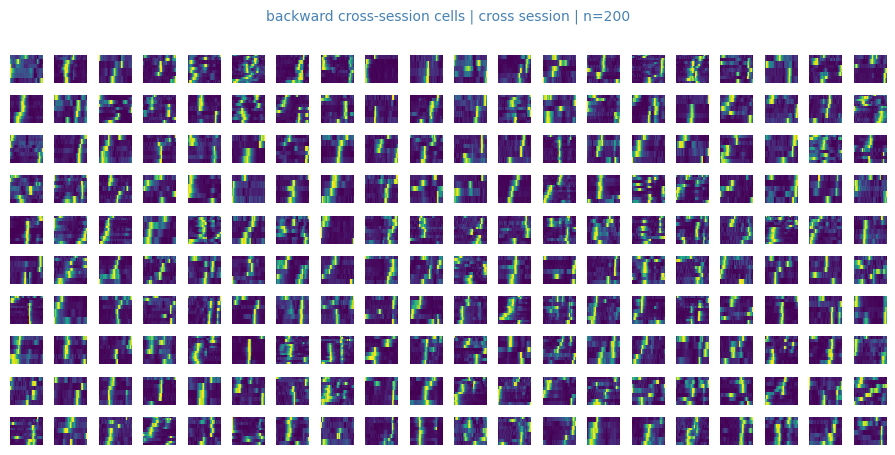

Saved: /home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/backward_trial_by_trial_selected_200_cells.pdf


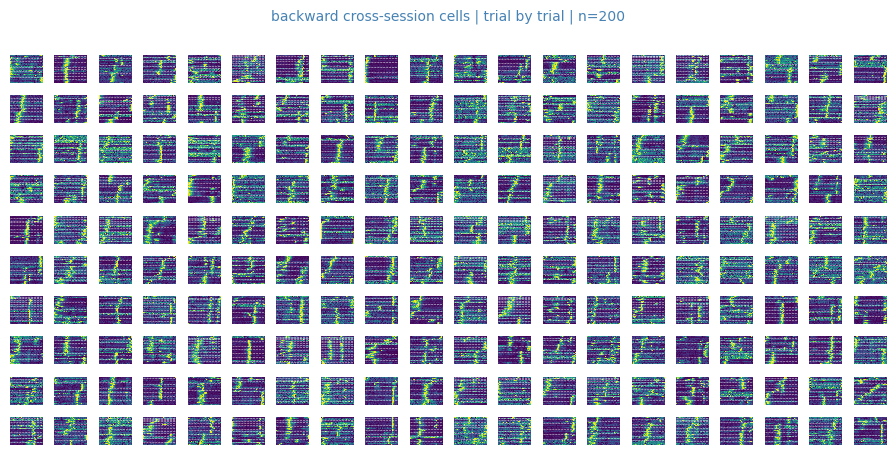

Saved: /home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/stable_cross_session_selected_200_cells.pdf


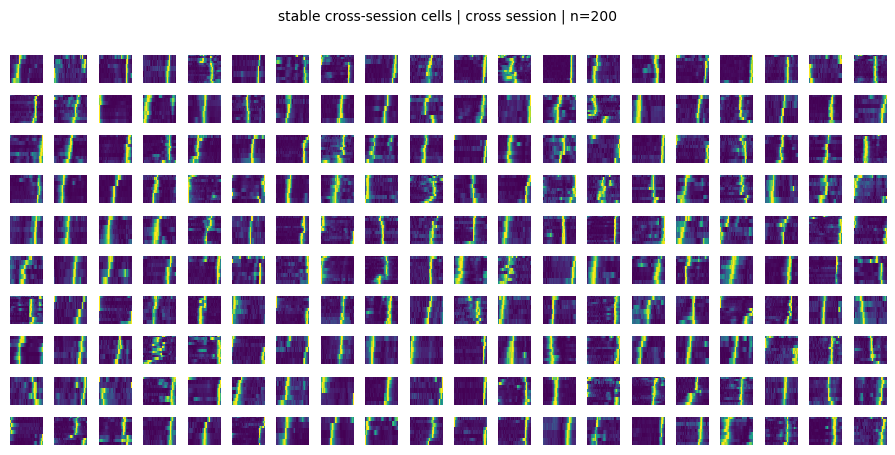

Saved: /home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/stable_trial_by_trial_selected_200_cells.pdf


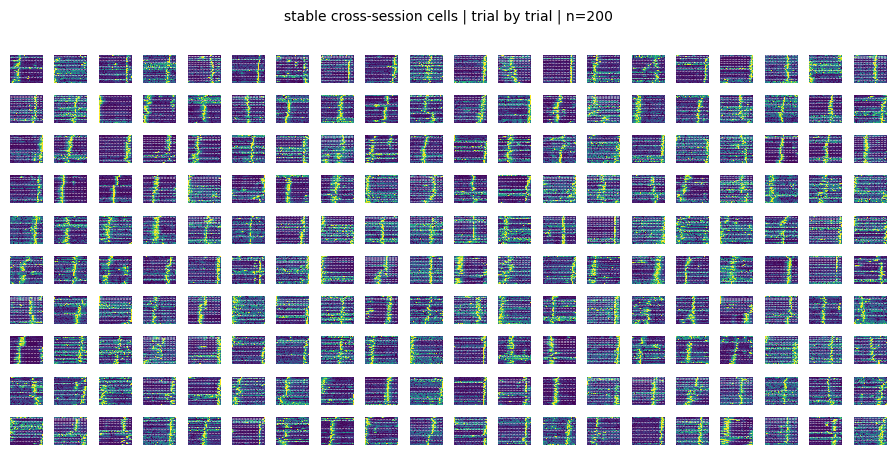

Saved: /home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/forward_cross_session_selected_200_cells.pdf


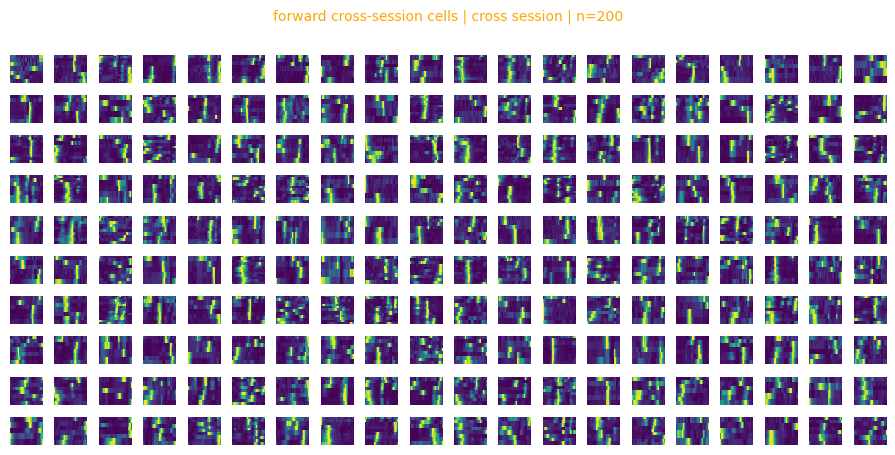

Saved: /home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/forward_trial_by_trial_selected_200_cells.pdf


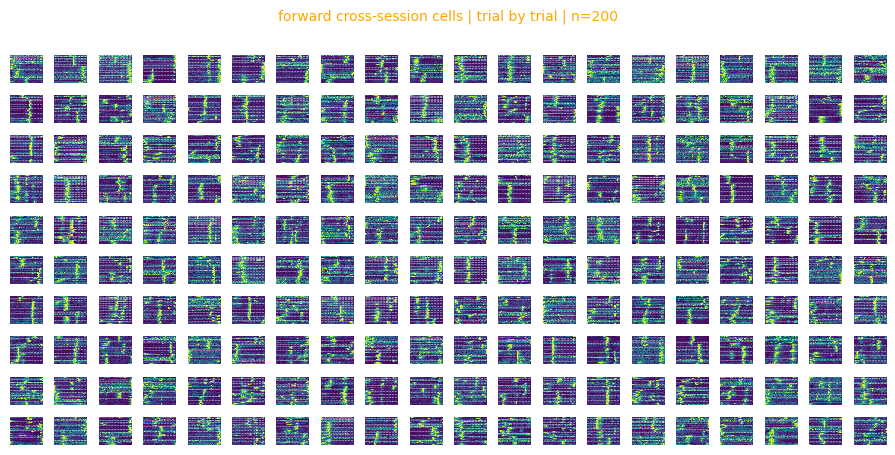

Saved: /home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/neither_cross_session_selected_200_cells.pdf


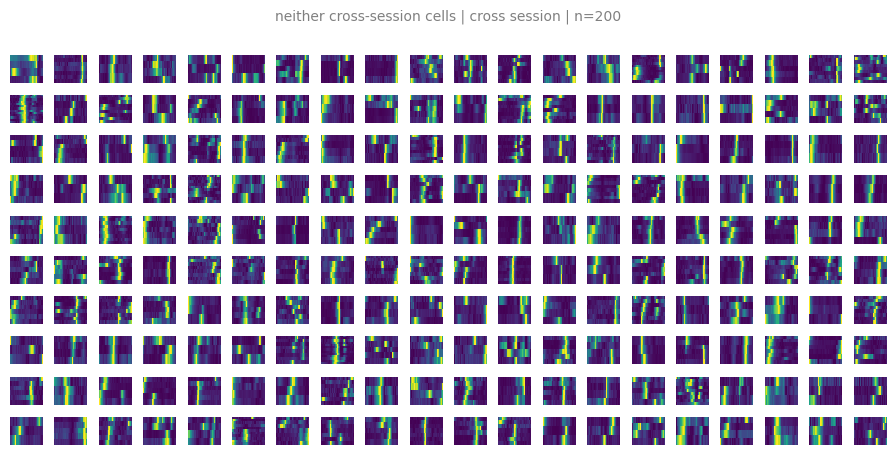

Saved: /home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/neither_trial_by_trial_selected_200_cells.pdf


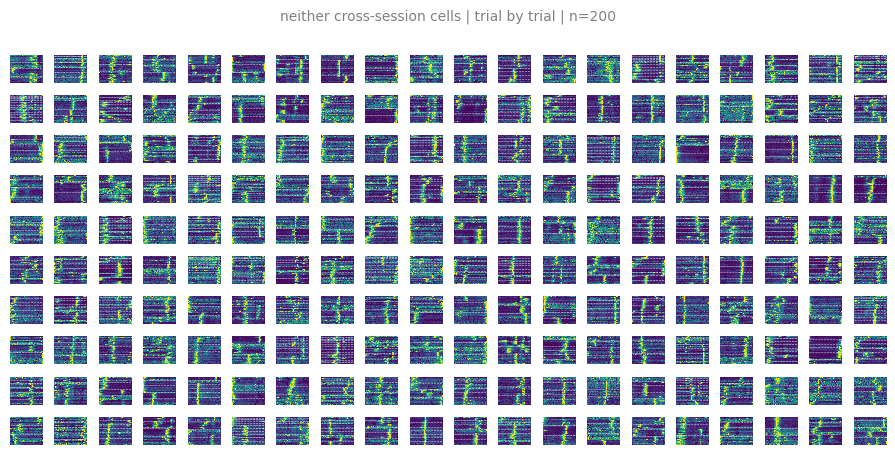

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings

save_dir = "/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper"
os.makedirs(save_dir, exist_ok=True)

classes = ["backward", "stable", "forward", "neither"]
class_colors = {
    "backward": "steelblue",
    "stable": "black",
    "forward": "orange",
    "neither": "gray"
}

n_cells_per_class = 200
rng = np.random.default_rng(0)

# -------------------------------------------------------
# helper: normalize each row 0-1
# -------------------------------------------------------
def norm_rows_01(mat):
    mat = np.asarray(mat, float)
    out = mat.copy()

    mn = np.nanmin(out, axis=1, keepdims=True)
    mx = np.nanmax(out, axis=1, keepdims=True)

    denom = mx - mn
    denom[denom == 0] = np.nan

    out = (out - mn) / denom
    return out


# -------------------------------------------------------
# helper: concatenate trial-by-trial PFs across involved sessions
# -------------------------------------------------------
def get_trial_by_trial_concat(animal, cell, trial_type, sessions):

    data = Data_trial[animal]
    mats = []
    session_boundaries = []
    n_so_far = 0

    for sess in sessions:

        PF_all = np.asarray(data["fields"][int(sess)], float)
        tt = np.asarray(data["trial_types"][int(sess)])

        trial_idx = np.where(tt == trial_type)[0]
        PF = PF_all[trial_idx]

        if PF.shape[0] < 5:
            continue

        engaged = get_engaged_trials(PF, z_threshold=z_threshold)
        PF_engaged = PF[engaged]

        if PF_engaged.shape[0] < 5:
            continue

        mat = PF_engaged[:, int(cell), :]

        if np.all(~np.isfinite(mat)):
            continue

        mats.append(mat)
        n_so_far += mat.shape[0]
        session_boundaries.append(n_so_far)

    if len(mats) == 0:
        return None, []

    mat_cat = np.concatenate(mats, axis=0)
    return mat_cat, session_boundaries[:-1]


# -------------------------------------------------------
# helper: session-averaged PF matrix
# rows = sessions, cols = spatial bins
# -------------------------------------------------------
def get_cross_session_avg_matrix(animal, cell, trial_type, sessions):

    data = Data_trial[animal]
    mats = []

    for sess in sessions:

        PF_all = np.asarray(data["fields"][int(sess)], float)
        tt = np.asarray(data["trial_types"][int(sess)])

        trial_idx = np.where(tt == trial_type)[0]
        PF = PF_all[trial_idx]

        if PF.shape[0] < 5:
            continue

        engaged = get_engaged_trials(PF, z_threshold=z_threshold)
        PF_engaged = PF[engaged]

        if PF_engaged.shape[0] < 5:
            continue

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            mean_pf = np.nanmean(PF_engaged[:, int(cell), :], axis=0)

        if np.all(~np.isfinite(mean_pf)):
            continue

        mats.append(mean_pf)

    if len(mats) == 0:
        return None

    return np.asarray(mats)


# -------------------------------------------------------
# select cells from cross-session classes
# -------------------------------------------------------
selected_cells = {}

for lab in classes:

    d = df_pf_cross_session_dynamics[
        (df_pf_cross_session_dynamics["label"] == lab) &
        (df_pf_cross_session_dynamics["n_pc_sessions"] >= min_pc_sessions)
    ].copy()

    d = d[np.isfinite(d["slope"]) & np.isfinite(d["linearity"])]

    if len(d) > n_cells_per_class:
        d = d.sample(n=n_cells_per_class, random_state=0)

    selected_cells[lab] = d.reset_index(drop=True)

    print(lab, len(d))


# -------------------------------------------------------
# plot function: one class, 200 cells
# -------------------------------------------------------
def plot_class_cells(d_class, lab, mode="cross_session"):

    n = len(d_class)
    n_cols = 20
    n_rows = int(np.ceil(n / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(n_cols * 0.45, n_rows * 0.45),
        squeeze=False
    )

    axes = axes.ravel()

    for i, (_, row) in enumerate(d_class.iterrows()):

        ax = axes[i]

        animal = row["animal"]
        cell = int(row["cell"])
        trial_type = int(row["trial_type"])
        sessions = np.asarray(row["sessions"], dtype=int)

        if mode == "cross_session":
            mat = get_cross_session_avg_matrix(
                animal, cell, trial_type, sessions
            )
        else:
            mat, boundaries = get_trial_by_trial_concat(
                animal, cell, trial_type, sessions
            )

        if mat is None or mat.size == 0:
            ax.axis("off")
            continue

        mat = norm_rows_01(mat)

        mat = fill_nan_local_mean(mat, size=3)

        ax.imshow(
            mat,
            aspect="auto",
            cmap="viridis",
            interpolation="nearest",
            vmin=0,
            vmax=1)

        if mode == "trial_by_trial":
            for b in boundaries:
                ax.axhline(b - 0.5, color="w", lw=0.4, ls="--", alpha=0.8)

        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(False)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    title = (
        f"{lab} cross-session cells | {mode.replace('_', ' ')} | " f"n={n}")

    fig.suptitle(
        title,
        fontsize=10,
        color=class_colors[lab],
        y=0.995
    )

    plt.tight_layout(rect=[0, 0, 1, 0.98])

    save_path = os.path.join(
        save_dir,
        f"{lab}_{mode}_selected_{n}_cells.pdf"
    )

    fig.savefig(
        save_path,
        format="pdf",
        bbox_inches="tight",
        dpi=300
    )

    print(f"Saved: {save_path}")
    plt.show()


# -------------------------------------------------------
# generate PDFs
# -------------------------------------------------------
for lab in classes:

    d_class = selected_cells[lab]

    plot_class_cells(
        d_class,
        lab,
        mode="cross_session"
    )

    plot_class_cells(
        d_class,
        lab,
        mode="trial_by_trial"
    )


Animal: Tyche-A4
  TT1 | stable: n_cells=47, n_sessions=10
  TT1 | backward: n_cells=303, n_sessions=10
  TT1 | forward: n_cells=137, n_sessions=10
  TT1 | neither: n_cells=2092, n_sessions=10
  TT2 | stable: n_cells=41, n_sessions=10
  TT2 | backward: n_cells=298, n_sessions=10
  TT2 | forward: n_cells=126, n_sessions=10
  TT2 | neither: n_cells=2146, n_sessions=10

Animal: Tyche-A5
  TT1 | stable: n_cells=10, n_sessions=6
  TT1 | backward: n_cells=66, n_sessions=6
  TT1 | forward: n_cells=13, n_sessions=6
  TT1 | neither: n_cells=1459, n_sessions=6
  TT2 | stable: n_cells=11, n_sessions=6
  TT2 | backward: n_cells=72, n_sessions=6
  TT2 | forward: n_cells=15, n_sessions=6
  TT2 | neither: n_cells=1428, n_sessions=6

Animal: Tyche-A7
  TT1 | stable: n_cells=61, n_sessions=9
  TT1 | backward: n_cells=410, n_sessions=9
  TT1 | forward: n_cells=116, n_sessions=9
  TT1 | neither: n_cells=2637, n_sessions=9
  TT2 | stable: n_cells=70, n_sessions=9
  TT2 | backward: n_cells=392, n_sessions

/tmp/ipykernel_13495/3595266304.py:212: RuntimeWarning: Mean of empty slice
  shift_mat[i, j] = np.nanmean(shifts_cm)


  TT1 | backward: n_cells=26, n_sessions=7
  TT1 | neither: n_cells=408, n_sessions=7
  TT2 | backward: n_cells=27, n_sessions=7
  TT2 | forward: n_cells=6, n_sessions=7
  TT2 | neither: n_cells=474, n_sessions=7

stable:
  n matrices = 10
  mean n cells = 54.6
  min/max n cells = 9 / 163

backward:
  n matrices = 14
  mean n cells = 178.9
  min/max n cells = 15 / 410

forward:
  n matrices = 11
  mean n cells = 80.1
  min/max n cells = 6 / 159

neither:
  n matrices = 14
  mean n cells = 1441.0
  min/max n cells = 408 / 2637
Saved: /home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/PV_cross_session_10x10_displacement_subpopulations.pdf


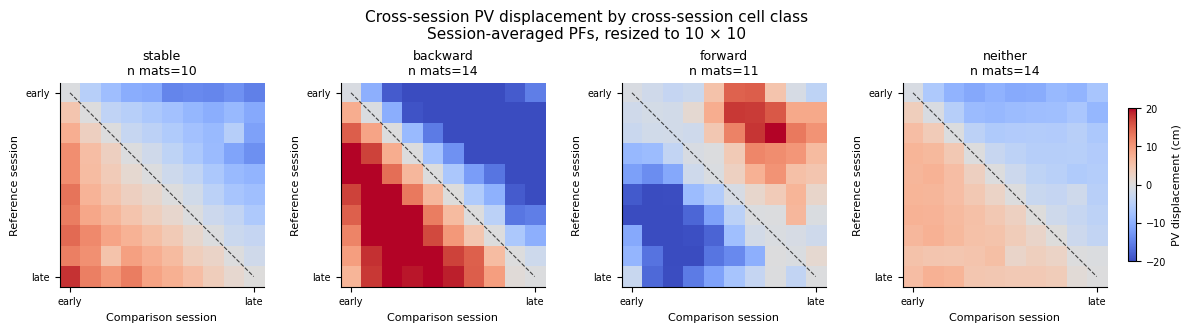

In [64]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from scipy.stats import t as t_dist

# ============================================================
# Parameters
# ============================================================

save_dir = "/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(
    save_dir,
    "PV_cross_session_10x10_displacement_subpopulations.pdf"
)

bin_size = 5
track_len = 230
alpha = 0.05
min_cells = 5
n_norm_sessions = 10

trial_types = [1, 2]
cell_groups = ["stable", "backward", "forward", "neither"]

vmin, vmax = -20, 20

# ============================================================
# PV correlation and displacement
# ============================================================

def pv_corr_matrix_nan_safe_fast(PV1, PV2, min_cells=5):
    X = np.asarray(PV1, float)
    Y = np.asarray(PV2, float)

    VX = np.isfinite(X).astype(float)
    VY = np.isfinite(Y).astype(float)

    X0 = np.nan_to_num(X, nan=0.0)
    Y0 = np.nan_to_num(Y, nan=0.0)

    N  = VX.T @ VY
    SX = X0.T @ VY
    SY = VX.T @ Y0

    with np.errstate(invalid="ignore", divide="ignore"):
        MX = SX / N
        MY = SY / N

        X2 = (X0 ** 2).T @ VY
        Y2 = VX.T @ (Y0 ** 2)
        XY = X0.T @ Y0

        cov = XY - N * MX * MY
        varX = X2 - N * MX ** 2
        varY = Y2 - N * MY ** 2

        denom = np.sqrt(varX * varY)
        M = cov / denom

        df = N - 2
        t_stat = M * np.sqrt(df / (1 - M ** 2))
        P = 2 * t_dist.sf(np.abs(t_stat), df)

    bad = (N <= min_cells) | (denom <= 0) | (df <= 0)

    M[bad] = np.nan
    P[bad] = np.nan

    return M, P


def displacement_from_M_centered_sig(
    M,
    P,
    bin_size=5,
    track_len=230,
    alpha=0.05
):
    n_bins = M.shape[1]
    disp = (np.arange(n_bins) - n_bins // 2) * bin_size

    shifts = np.full(M.shape[0], np.nan)

    for i in range(M.shape[0]):

        row = M[i].copy()
        row[P[i] >= alpha] = np.nan

        w = np.roll(row, n_bins // 2 - i)
        w = np.clip(w, 0, None)

        if np.isfinite(w).sum() < 3 or np.nansum(w) == 0:
            continue

        shifts[i] = np.nansum(w * disp) / np.nansum(w)

    return shifts


# ============================================================
# Helpers
# ============================================================

def resize_square_matrix(mat, target_n=10):
    """
    Resize n_session x n_session matrix to target_n x target_n.
    """
    mat = np.asarray(mat, float)

    if mat.shape[0] < 2 or mat.shape[1] < 2:
        return None

    zoom_factors = (
        target_n / mat.shape[0],
        target_n / mat.shape[1]
    )

    return zoom(mat, zoom_factors, order=1)


def get_session_avg_PF_by_tt(animal, trial_type):
    """
    Returns:
        session_pfs: list of cells x bins matrices
        sessions_used: corresponding session ids

    Each session matrix is averaged across all engaged trials
    of the given trial type.
    """

    data = Data_trial[animal]
    n_sessions = len(data["fields"])

    session_pfs = []
    sessions_used = []

    for sess in range(n_sessions):

        PF_all = np.asarray(data["fields"][sess], float)
        TT = np.asarray(data["trial_types"][sess])

        PF = PF_all[TT == trial_type]

        if PF.shape[0] < 5:
            continue

        engaged = get_engaged_trials(PF, z_threshold=z_threshold)
        PF_engaged = PF[engaged]

        if PF_engaged.shape[0] < 5:
            continue

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            mean_pf = np.nanmean(PF_engaged, axis=0)  # cells x bins

        if np.all(~np.isfinite(mean_pf)):
            continue

        session_pfs.append(mean_pf)
        sessions_used.append(sess)

    return session_pfs, np.asarray(sessions_used)


def session_pair_displacement_matrix(
    session_pfs,
    cell_idx,
    alpha=0.05,
    min_cells=5,
    bin_size=5,
    track_len=230
):
    """
    session_pfs: list of session-averaged PFs, each cells x bins
    cell_idx: cells selected by cross-session class

    Returns:
        n_sessions x n_sessions displacement matrix
    """

    n_sessions = len(session_pfs)
    shift_mat = np.full((n_sessions, n_sessions), np.nan)

    if len(cell_idx) < min_cells:
        return shift_mat

    session_sub = [pf[cell_idx, :] for pf in session_pfs]

    for i in range(n_sessions):
        for j in range(n_sessions):

            M, P = pv_corr_matrix_nan_safe_fast(
                session_sub[i],
                session_sub[j],
                min_cells=min_cells
            )

            shifts_cm = displacement_from_M_centered_sig(
                M,
                P,
                bin_size=bin_size,
                track_len=track_len,
                alpha=alpha
            )

            shift_mat[i, j] = np.nanmean(shifts_cm)

    return shift_mat


# ============================================================
# Main cross-session analysis
# ============================================================

all_mats = {g: [] for g in cell_groups}
all_counts = {g: [] for g in cell_groups}
all_meta = {g: [] for g in cell_groups}

for animal in animals:

    print(f"\nAnimal: {animal}")

    for trial_type in trial_types:

        session_pfs, sessions_used = get_session_avg_PF_by_tt(
            animal,
            trial_type
        )

        if len(session_pfs) < 3:
            continue

        for group in cell_groups:

            df_group = df_pf_cross_session_dynamics[
                (df_pf_cross_session_dynamics["animal"] == animal) &
                (df_pf_cross_session_dynamics["trial_type"] == trial_type) &
                (df_pf_cross_session_dynamics["label"] == group) &
                (df_pf_cross_session_dynamics["n_pc_sessions"] >= min_pc_sessions)
            ].copy()

            if len(df_group) == 0:
                continue

            cell_idx = (
                df_group["cell"]
                .dropna()
                .astype(int)
                .unique()
            )

            if len(cell_idx) < min_cells:
                continue

            shift_mat = session_pair_displacement_matrix(
                session_pfs,
                cell_idx,
                alpha=alpha,
                min_cells=min_cells,
                bin_size=bin_size,
                track_len=track_len
            )

            if np.isfinite(shift_mat).sum() == 0:
                continue

            shift_mat_10 = resize_square_matrix(
                shift_mat,
                target_n=n_norm_sessions
            )

            if shift_mat_10 is None or np.isfinite(shift_mat_10).sum() == 0:
                continue

            all_mats[group].append(shift_mat_10)
            all_counts[group].append(len(cell_idx))
            all_meta[group].append({
                "animal": animal,
                "trial_type": trial_type,
                "n_original_sessions": len(session_pfs),
                "sessions_used": sessions_used,
                "n_cells": len(cell_idx)
            })

            print(
                f"  TT{trial_type} | {group}: "
                f"n_cells={len(cell_idx)}, "
                f"n_sessions={len(session_pfs)}"
            )




stable:
  n matrices = 10
  mean n cells = 54.6
  min/max n cells = 9 / 163

backward:
  n matrices = 14
  mean n cells = 178.9
  min/max n cells = 15 / 410

forward:
  n matrices = 11
  mean n cells = 80.1
  min/max n cells = 6 / 159

neither:
  n matrices = 14
  mean n cells = 1441.0
  min/max n cells = 408 / 2637
Saved: /home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/PV_cross_session_10x10_displacement_subpopulations.pdf


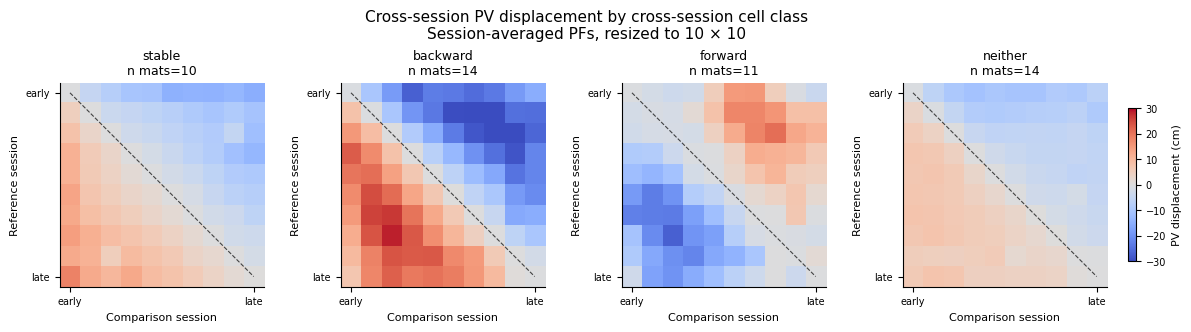

In [68]:

# ============================================================
# Average across animals and trial types
# ============================================================

mean_mats = {}

for group in cell_groups:

    if len(all_mats[group]) == 0:
        mean_mats[group] = np.full((n_norm_sessions, n_norm_sessions), np.nan)
        print(f"\n{group}: no valid matrices")
        continue

    mats = np.stack(all_mats[group], axis=0)

    mean_mats[group] = np.nanmean(mats, axis=0)

    print(
        f"\n{group}:"
        f"\n  n matrices = {len(all_mats[group])}"
        f"\n  mean n cells = {np.nanmean(all_counts[group]):.1f}"
        f"\n  min/max n cells = "
        f"{np.nanmin(all_counts[group])} / {np.nanmax(all_counts[group])}"
    )


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1,
    len(cell_groups),
    figsize=(3.0 * len(cell_groups), 3.2),
    constrained_layout=True
)

if len(cell_groups) == 1:
    axes = [axes]

for ax, group in zip(axes, cell_groups):

    im = ax.imshow(
        mean_mats[group],
        cmap="coolwarm",
        vmin=-30,
        vmax=30,
        origin="upper",
        aspect="equal"
    )

    ax.plot(
        np.arange(n_norm_sessions),
        np.arange(n_norm_sessions),
        color="k",
        ls="--",
        lw=0.8,
        alpha=0.7
    )

    ax.set_title(
        f"{group}\n"
        f"n mats={len(all_mats[group])}"
    )

    ax.set_xlabel("Comparison session")
    ax.set_ylabel("Reference session")

    ax.set_xticks([0, n_norm_sessions - 1])
    ax.set_xticklabels(["early", "late"])

    ax.set_yticks([0, n_norm_sessions - 1])
    ax.set_yticklabels(["early", "late"])

cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=0.75,
    pad=0.02
)

cbar.set_label("PV displacement (cm)")

fig.suptitle(
    "Cross-session PV displacement by cross-session cell class\n"
    "Session-averaged PFs, resized to 10 × 10",
    fontsize=11
)

fig.savefig(
    save_path,
    format="pdf",
    bbox_inches="tight",
    dpi=300
)

print(f"Saved: {save_path}")

plt.show()

In [84]:
import os
import warnings
import numpy as np
import pandas as pd
from scipy.ndimage import zoom
from scipy.stats import t as t_dist

# ============================================================
# Parameters
# ============================================================

save_dir = "/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper"
os.makedirs(save_dir, exist_ok=True)

bin_size = 5
track_len = 230
alpha = 0.05
min_cells = 5
n_norm_sessions = 10
trial_types = [1, 2]

# ============================================================
# PV correlation + displacement
# ============================================================

def pv_corr_matrix_nan_safe_fast(PV1, PV2, min_cells=5):

    X = np.asarray(PV1, float)
    Y = np.asarray(PV2, float)

    VX = np.isfinite(X).astype(float)
    VY = np.isfinite(Y).astype(float)

    X0 = np.nan_to_num(X, nan=0.0)
    Y0 = np.nan_to_num(Y, nan=0.0)

    N  = VX.T @ VY
    SX = X0.T @ VY
    SY = VX.T @ Y0

    with np.errstate(invalid="ignore", divide="ignore"):
        MX = SX / N
        MY = SY / N

        X2 = (X0 ** 2).T @ VY
        Y2 = VX.T @ (Y0 ** 2)
        XY = X0.T @ Y0

        cov = XY - N * MX * MY
        varX = X2 - N * MX ** 2
        varY = Y2 - N * MY ** 2

        denom = np.sqrt(varX * varY)

        M = cov / denom

        df = N - 2
        t_stat = M * np.sqrt(df / (1 - M ** 2))
        P = 2 * t_dist.sf(np.abs(t_stat), df)

    bad = (N <= min_cells) | (denom <= 0) | (df <= 0)

    M[bad] = np.nan
    P[bad] = np.nan

    return M, P


def displacement_from_M_centered_sig(
    M,
    P,
    bin_size=5,
    track_len=230,
    alpha=0.05
):

    n_bins = M.shape[1]
    disp = (np.arange(n_bins) - n_bins // 2) * bin_size

    shifts = np.full(M.shape[0], np.nan)

    for i in range(M.shape[0]):

        row = M[i].copy()
        row[P[i] >= alpha] = np.nan

        w = np.roll(row, n_bins // 2 - i)
        w = np.clip(w, 0, None)

        if np.isfinite(w).sum() < 3 or np.nansum(w) == 0:
            continue

        shifts[i] = np.nansum(w * disp) / np.nansum(w)

    return shifts


# ============================================================
# Helpers
# ============================================================

def resize_square_matrix(mat, target_n=10):

    mat = np.asarray(mat, float)

    if mat.shape[0] < 2 or mat.shape[1] < 2:
        return None

    zoom_factors = (
        target_n / mat.shape[0],
        target_n / mat.shape[1]
    )

    return zoom(mat, zoom_factors, order=1)


def get_session_avg_PF_all_cells(animal, trial_type):

    data = Data_trial[animal]
    n_sessions = len(data["fields"])

    session_pfs = []
    sessions_used = []

    for sess in range(n_sessions):

        PF_all = np.asarray(data["fields"][sess], float)
        TT = np.asarray(data["trial_types"][sess])

        PF = PF_all[TT == trial_type]

        if PF.shape[0] < 5:
            continue

        engaged = get_engaged_trials(PF, z_threshold=z_threshold)
        PF_engaged = PF[engaged]

        if PF_engaged.shape[0] < 5:
            continue

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            mean_pf = np.nanmean(PF_engaged, axis=0)  # cells x bins

        if np.all(~np.isfinite(mean_pf)):
            continue

        session_pfs.append(mean_pf)
        sessions_used.append(sess)

    return session_pfs, np.asarray(sessions_used)


def align_session_pfs_to_reference_peak(session_pfs):
    """
    Correct cross-session PF alignment.

    For each cell:
        1. Find the session where that cell has max PF amplitude.
        2. In that reference session, find the PF peak position.
        3. For every other session, find that session's PF peak.
        4. Circularly shift that session's PF so its peak aligns to the
           reference-session peak.

    Input:
        session_pfs: list of session matrices, each cells x bins

    Output:
        aligned_pfs: list of aligned session matrices, same shape as input
    """

    S = len(session_pfs)
    n_cells, n_bins = session_pfs[0].shape

    arr = np.stack(session_pfs, axis=0)  # sessions x cells x bins
    aligned = np.full_like(arr, np.nan, dtype=float)

    for cell in range(n_cells):

        cell_mat = arr[:, cell, :]  # sessions x bins

        if np.all(~np.isfinite(cell_mat)):
            continue

        # amplitude of this cell in each session
        amp = np.nanmax(cell_mat, axis=1)

        if np.all(~np.isfinite(amp)):
            continue

        # reference session = session with max amplitude
        ref_sess_idx = int(np.nanargmax(amp))
        ref_curve = cell_mat[ref_sess_idx]

        if np.all(~np.isfinite(ref_curve)):
            continue

        # reference peak position
        ref_peak_bin = int(np.nanargmax(ref_curve))

        # align every session peak to reference peak
        for s in range(S):

            curve = cell_mat[s]

            if np.all(~np.isfinite(curve)):
                continue

            peak_bin_s = int(np.nanargmax(curve))

            shift = ref_peak_bin - peak_bin_s

            aligned[s, cell, :] = np.roll(curve, shift)

    aligned_pfs = [aligned[s] for s in range(S)]

    return aligned_pfs

def session_pair_displacement_matrix_all_cells(
    session_pfs,
    alpha=0.05,
    min_cells=5,
    bin_size=5,
    track_len=230
):

    n_sessions = len(session_pfs)
    shift_mat = np.full((n_sessions, n_sessions), np.nan)

    n_cells = session_pfs[0].shape[0]
    cell_idx = np.arange(n_cells)

    if len(cell_idx) < min_cells:
        return shift_mat

    for i in range(n_sessions):
        for j in range(n_sessions):

            PV1 = session_pfs[i][cell_idx, :]
            PV2 = session_pfs[j][cell_idx, :]

            M, P = pv_corr_matrix_nan_safe_fast(
                PV1,
                PV2,
                min_cells=min_cells
            )

            shifts_cm = displacement_from_M_centered_sig(
                M,
                P,
                bin_size=bin_size,
                track_len=track_len,
                alpha=alpha
            )

            shift_mat[i, j] = np.nanmean(shifts_cm)

    return shift_mat


# ============================================================
# Main analysis: original vs aligned
# ============================================================

all_session_mats = {
    "original": [],
    "aligned": []
}

all_meta = {
    "original": [],
    "aligned": []
}

for animal in animals:

    print(f"\nAnimal: {animal}")

    for trial_type in trial_types:

        session_pfs, sessions_used = get_session_avg_PF_all_cells(
            animal,
            trial_type
        )

        if len(session_pfs) < 3:
            continue

        # -------------------------
        # Original
        # -------------------------
        shift_original = session_pair_displacement_matrix_all_cells(
            session_pfs,
            alpha=alpha,
            min_cells=min_cells,
            bin_size=bin_size,
            track_len=track_len
        )

        shift_original_10 = resize_square_matrix(
            shift_original,
            target_n=n_norm_sessions
        )

        if shift_original_10 is not None and np.isfinite(shift_original_10).sum() > 0:

            all_session_mats["original"].append(shift_original_10)

            all_meta["original"].append({
                "animal": animal,
                "trial_type": trial_type,
                "n_sessions": len(session_pfs),
                "sessions_used": sessions_used,
                "n_cells": session_pfs[0].shape[0]
            })

        # -------------------------
        # Aligned
        # -------------------------
        aligned_pfs = align_session_pfs_to_reference_peak(session_pfs)

        shift_aligned = session_pair_displacement_matrix_all_cells(
            aligned_pfs,
            alpha=alpha,
            min_cells=min_cells,
            bin_size=bin_size,
            track_len=track_len
        )

        shift_aligned_10 = resize_square_matrix(
            shift_aligned,
            target_n=n_norm_sessions
        )

        if shift_aligned_10 is not None and np.isfinite(shift_aligned_10).sum() > 0:

            all_session_mats["aligned"].append(shift_aligned_10)

            all_meta["aligned"].append({
                "animal": animal,
                "trial_type": trial_type,
                "n_sessions": len(session_pfs),
                "sessions_used": sessions_used,
                "n_cells": session_pfs[0].shape[0]
            })

        print(
            f"  TT{trial_type}: "
            f"n_sessions={len(session_pfs)}, "
            f"n_cells={session_pfs[0].shape[0]}"
        )


# ============================================================
# Average matrices
# ============================================================

mean_session_mats = {}

for condition in ["original", "aligned"]:

    if len(all_session_mats[condition]) == 0:
        mean_session_mats[condition] = np.full(
            (n_norm_sessions, n_norm_sessions),
            np.nan
        )
        continue

    mats = np.stack(all_session_mats[condition], axis=0)

    mean_session_mats[condition] = np.nanmean(mats, axis=0)

    print(
        f"\n{condition}:"
        f"\n  n matrices = {len(all_session_mats[condition])}"
        f"\n  mean n cells = {np.nanmean([m['n_cells'] for m in all_meta[condition]]):.1f}"
    )


Animal: Tyche-A4
  TT1: n_sessions=10, n_cells=3906
  TT2: n_sessions=10, n_cells=3906

Animal: Tyche-A5
  TT1: n_sessions=6, n_cells=4254
  TT2: n_sessions=6, n_cells=4254

Animal: Tyche-A7
  TT1: n_sessions=9, n_cells=5354
  TT2: n_sessions=9, n_cells=5354

Animal: Tyche-B2
  TT1: n_sessions=7, n_cells=3034
  TT2: n_sessions=7, n_cells=3034

Animal: Tyche-B3
  TT1: n_sessions=15, n_cells=4240
  TT2: n_sessions=15, n_cells=4240

Animal: Tyche-B4
  TT1: n_sessions=5, n_cells=4924
  TT2: n_sessions=5, n_cells=4924

Animal: Tyche-B5
  TT1: n_sessions=7, n_cells=3385
  TT2: n_sessions=7, n_cells=3385

original:
  n matrices = 14
  mean n cells = 4156.7

aligned:
  n matrices = 14
  mean n cells = 4156.7


Saved: /home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/PV_cross_session_all_cells_original_vs_aligned.pdf


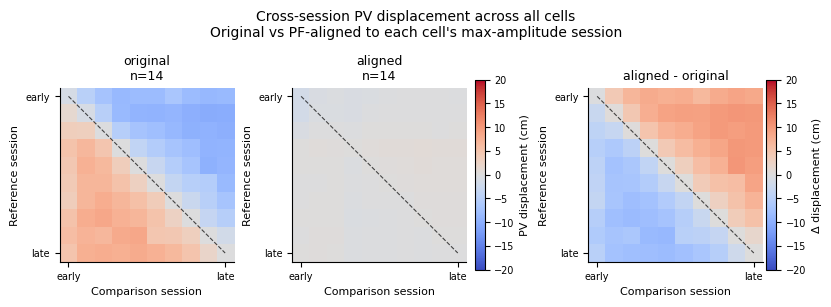

In [85]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Parameters
# ============================================================

save_dir = "/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(
    save_dir,
    "PV_cross_session_all_cells_original_vs_aligned.pdf"
)

vmin, vmax = -20, 20

plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ============================================================
# Plot
# ============================================================

conditions = ["original", "aligned"]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(8.2, 3.0),
    gridspec_kw={"width_ratios": [1, 1, 1]},
    constrained_layout=True
)

# -------------------------
# Original and aligned matrices
# -------------------------
for ax, condition in zip(axes[:2], conditions):

    im = ax.imshow(
        mean_session_mats[condition],
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax,
        origin="upper",
        aspect="equal"
    )

    ax.plot(
        np.arange(n_norm_sessions),
        np.arange(n_norm_sessions),
        color="k",
        ls="--",
        lw=0.8,
        alpha=0.7
    )

    ax.set_title(
        f"{condition}\n"
        f"n={len(all_session_mats[condition])}"
    )

    ax.set_xlabel("Comparison session")
    ax.set_ylabel("Reference session")

    ax.set_xticks([0, n_norm_sessions - 1])
    ax.set_xticklabels(["early", "late"])

    ax.set_yticks([0, n_norm_sessions - 1])
    ax.set_yticklabels(["early", "late"])

# -------------------------
# Difference: aligned - original
# -------------------------
diff_mat = mean_session_mats["aligned"] - mean_session_mats["original"]

im_diff = axes[2].imshow(
    diff_mat,
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    origin="upper",
    aspect="equal"
)

axes[2].plot(
    np.arange(n_norm_sessions),
    np.arange(n_norm_sessions),
    color="k",
    ls="--",
    lw=0.8,
    alpha=0.7
)

axes[2].set_title("aligned - original")
axes[2].set_xlabel("Comparison session")
axes[2].set_ylabel("Reference session")

axes[2].set_xticks([0, n_norm_sessions - 1])
axes[2].set_xticklabels(["early", "late"])

axes[2].set_yticks([0, n_norm_sessions - 1])
axes[2].set_yticklabels(["early", "late"])

# -------------------------
# Colorbar
# -------------------------
cbar = fig.colorbar(
    im,
    ax=axes[:2],
    shrink=0.75,
    pad=0.02
)
cbar.set_label("PV displacement (cm)")

cbar2 = fig.colorbar(
    im_diff,
    ax=axes[2],
    shrink=0.75,
    pad=0.02
)
cbar2.set_label("Δ displacement (cm)")

fig.suptitle(
    "Cross-session PV displacement across all cells\n"
    "Original vs PF-aligned to each cell's max-amplitude session",
    fontsize=10
)

fig.savefig(
    save_path,
    format="pdf",
    bbox_inches="tight",
    dpi=300
)

print(f"Saved: {save_path}")

plt.show()

original | Tyche-A4 | TT1: 9 consecutive pairs
original | Tyche-A4 | TT2: 9 consecutive pairs
original | Tyche-A5 | TT1: 5 consecutive pairs
original | Tyche-A5 | TT2: 5 consecutive pairs
original | Tyche-A7 | TT1: 8 consecutive pairs
original | Tyche-A7 | TT2: 8 consecutive pairs
original | Tyche-B2 | TT1: 6 consecutive pairs
original | Tyche-B2 | TT2: 6 consecutive pairs
original | Tyche-B3 | TT1: 14 consecutive pairs
original | Tyche-B3 | TT2: 14 consecutive pairs
original | Tyche-B4 | TT1: 4 consecutive pairs
original | Tyche-B4 | TT2: 4 consecutive pairs
original | Tyche-B5 | TT1: 6 consecutive pairs
original | Tyche-B5 | TT2: 6 consecutive pairs
peak_aligned | Tyche-A4 | TT1: 9 consecutive pairs
peak_aligned | Tyche-A4 | TT2: 9 consecutive pairs
peak_aligned | Tyche-A5 | TT1: 5 consecutive pairs
peak_aligned | Tyche-A5 | TT2: 5 consecutive pairs
peak_aligned | Tyche-A7 | TT1: 8 consecutive pairs
peak_aligned | Tyche-A7 | TT2: 8 consecutive pairs
peak_aligned | Tyche-B2 | TT1: 6 c

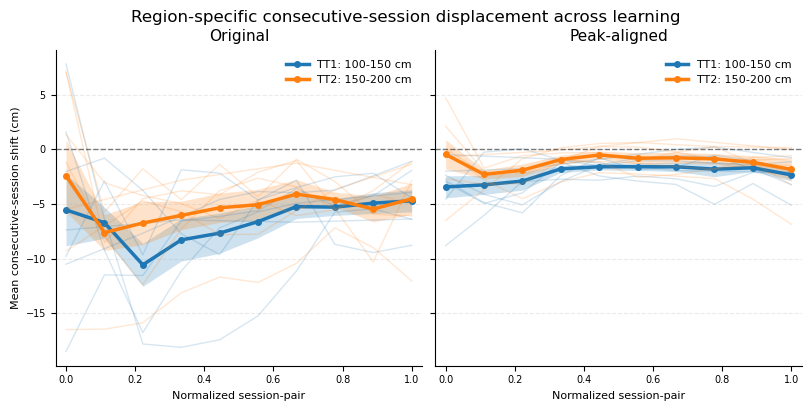

Saved PDF:
/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/region_specific_consecutive_session_displacement_original_vs_peak_aligned.pdf


In [86]:
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings

save_dir = "/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper"
os.makedirs(save_dir, exist_ok=True)

n_norm_sessions = 10
norm_x = np.linspace(0, 1, n_norm_sessions)

region_by_tt = {
    1: (100, 150),
    2: (150, 200)
}

colors = {
    1: "tab:blue",
    2: "tab:orange"
}

group_labels = {
    "original": "Original",
    "peak_aligned": "Peak-aligned"
}

# ============================================================
# Build session-averaged PFs
# ============================================================

def get_session_avg_PFs(animal, trial_type):

    data = Data_trial[animal]
    n_sessions = len(data["fields"])

    session_pfs = []
    sessions_used = []

    for sess in range(n_sessions):

        PF_all = np.asarray(data["fields"][sess], float)
        TT = np.asarray(data["trial_types"][sess])

        PF = PF_all[TT == trial_type]

        if PF.shape[0] < 5:
            continue

        engaged = get_engaged_trials(PF, z_threshold=z_threshold)
        PF_engaged = PF[engaged]

        if PF_engaged.shape[0] < 5:
            continue

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            mean_pf = np.nanmean(PF_engaged, axis=0)  # cells x bins

        if np.all(~np.isfinite(mean_pf)):
            continue

        session_pfs.append(mean_pf)
        sessions_used.append(sess)

    return session_pfs, np.asarray(sessions_used)


# ============================================================
# Correct peak alignment across sessions
# ============================================================

def align_session_pfs_to_reference_peak(session_pfs):

    S = len(session_pfs)
    n_cells, n_bins = session_pfs[0].shape

    arr = np.stack(session_pfs, axis=0)  # sessions x cells x bins
    aligned = np.full_like(arr, np.nan, dtype=float)

    for cell in range(n_cells):

        cell_mat = arr[:, cell, :]

        if np.all(~np.isfinite(cell_mat)):
            continue

        amp = np.nanmax(cell_mat, axis=1)

        if np.all(~np.isfinite(amp)):
            continue

        ref_sess_idx = int(np.nanargmax(amp))
        ref_curve = cell_mat[ref_sess_idx]

        if np.all(~np.isfinite(ref_curve)):
            continue

        ref_peak_bin = int(np.nanargmax(ref_curve))

        for s in range(S):

            curve = cell_mat[s]

            if np.all(~np.isfinite(curve)):
                continue

            peak_bin_s = int(np.nanargmax(curve))
            shift = ref_peak_bin - peak_bin_s

            aligned[s, cell, :] = np.roll(curve, shift)

    return [aligned[s] for s in range(S)]


# ============================================================
# Consecutive-session displacement
# ============================================================

def consecutive_session_shift_vectors(
    session_pfs,
    alpha=0.05,
    min_cells=5,
    bin_size=5,
    track_len=230
):

    n_sessions = len(session_pfs)
    shift_vectors = []

    for i in range(n_sessions - 1):

        PV1 = session_pfs[i]
        PV2 = session_pfs[i + 1]

        M, P = pv_corr_matrix_nan_safe_fast(
            PV1,
            PV2,
            min_cells=min_cells
        )

        shifts_cm = displacement_from_M_centered_sig(
            M,
            P,
            bin_size=bin_size,
            track_len=track_len,
            alpha=alpha
        )

        shift_vectors.append(shifts_cm)

    return np.asarray(shift_vectors)  # session-pairs x bins


# ============================================================
# Main analysis
# ============================================================

session_shift_consecutive_by_group_animal_tt = {
    "original": {},
    "peak_aligned": {}
}

for group in ["original", "peak_aligned"]:

    for animal in animals:

        session_shift_consecutive_by_group_animal_tt[group][animal] = {}

        for trial_type in [1, 2]:

            session_pfs, sessions_used = get_session_avg_PFs(
                animal,
                trial_type
            )

            if len(session_pfs) < 3:
                session_shift_consecutive_by_group_animal_tt[group][animal][trial_type] = {
                    "matrix": np.empty((0, int(track_len / bin_size))),
                    "sessions": np.array([])
                }
                continue

            if group == "peak_aligned":
                session_pfs = align_session_pfs_to_reference_peak(session_pfs)

            shift_mat = consecutive_session_shift_vectors(
                session_pfs,
                alpha=alpha,
                min_cells=min_cells,
                bin_size=bin_size,
                track_len=track_len
            )

            # session-pair label = starting session
            pair_sessions = sessions_used[:-1]

            session_shift_consecutive_by_group_animal_tt[group][animal][trial_type] = {
                "matrix": shift_mat,
                "sessions": pair_sessions,
                "sessions_used": sessions_used
            }

            print(
                f"{group} | {animal} | TT{trial_type}: "
                f"{shift_mat.shape[0]} consecutive pairs"
            )


# ============================================================
# Interpolate region-specific consecutive-session shifts
# ============================================================

curve_by_group_animal_tt = {}
interp_curve_by_group_tt = {}

for group in ["original", "peak_aligned"]:

    curve_by_group_animal_tt[group] = {}
    interp_curve_by_group_tt[group] = {}

    session_shift_matrix = session_shift_consecutive_by_group_animal_tt[group]

    for trial_type in [1, 2]:

        region_cm = region_by_tt[trial_type]
        b0 = int(region_cm[0] / bin_size)
        b1 = int(region_cm[1] / bin_size)

        interp_curves = []
        animals_used = []

        for animal in animals:

            mat = session_shift_matrix[animal][trial_type]["matrix"]
            sessions = session_shift_matrix[animal][trial_type]["sessions"]

            if mat.size == 0 or mat.shape[0] < 2:
                continue

            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=RuntimeWarning)
                y = np.nanmean(mat[:, b0:b1], axis=1)

            valid = np.isfinite(y)

            if valid.sum() < 2:
                continue

            sess = sessions.astype(float)

            if np.nanmax(sess) == np.nanmin(sess):
                continue

            sess_norm = (
                sess - np.nanmin(sess)
            ) / (
                np.nanmax(sess) - np.nanmin(sess)
            )

            f = interp1d(
                sess_norm[valid],
                y[valid],
                kind="linear",
                bounds_error=False,
                fill_value="extrapolate"
            )

            y_interp = f(norm_x)

            interp_curves.append(y_interp)
            animals_used.append(animal)

            curve_by_group_animal_tt[group][(animal, trial_type)] = {
                "sessions": sessions,
                "session_norm": sess_norm,
                "raw_curve": y,
                "interp_curve": y_interp,
                "region_cm": region_cm
            }

        interp_curves = np.asarray(interp_curves)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)

            mean_curve = np.nanmean(interp_curves, axis=0)

            if interp_curves.shape[0] > 1:
                sem_curve = (
                    np.nanstd(interp_curves, axis=0, ddof=1)
                    / np.sqrt(interp_curves.shape[0])
                )
            else:
                sem_curve = np.full_like(mean_curve, np.nan)

        interp_curve_by_group_tt[group][trial_type] = {
            "interp_curves": interp_curves,
            "mean": mean_curve,
            "sem": sem_curve,
            "animals_used": animals_used,
            "region_cm": region_cm,
            "norm_x": norm_x
        }


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(8.0, 3.8),
    constrained_layout=True,
    sharex=True,
    sharey=True
)

for ax, group in zip(axes, ["original", "peak_aligned"]):

    for trial_type in [1, 2]:

        d = interp_curve_by_group_tt[group][trial_type]

        curves = d["interp_curves"]
        mean_curve = d["mean"]
        sem_curve = d["sem"]
        region_cm = d["region_cm"]

        for y in curves:
            ax.plot(
                norm_x,
                y,
                color=colors[trial_type],
                alpha=0.18,
                lw=1
            )

        ax.plot(
            norm_x,
            mean_curve,
            "-o",
            color=colors[trial_type],
            lw=2.5,
            ms=4,
            label=f"TT{trial_type}: {region_cm[0]}-{region_cm[1]} cm"
        )

        ax.fill_between(
            norm_x,
            mean_curve - sem_curve,
            mean_curve + sem_curve,
            color=colors[trial_type],
            alpha=0.22,
            linewidth=0
        )

    ax.axhline(0, color="k", ls="--", lw=1, alpha=0.5)

    ax.set_title(group_labels[group], fontsize=11)
    ax.set_xlabel("Normalized session-pair")
    ax.set_xlim(-0.03, 1.03)
    ax.set_xticks(np.linspace(0, 1, 6))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(axis="y", alpha=0.25, linestyle="--")
    ax.legend(frameon=False, fontsize=8)

axes[0].set_ylabel("Mean consecutive-session shift (cm)")

fig.suptitle(
    "Region-specific consecutive-session displacement across learning",
    fontsize=12,
    y=1.04
)

pdf_path = os.path.join(
    save_dir,
    "region_specific_consecutive_session_displacement_original_vs_peak_aligned.pdf"
)

fig.savefig(
    pdf_path,
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

print(f"Saved PDF:\n{pdf_path}")

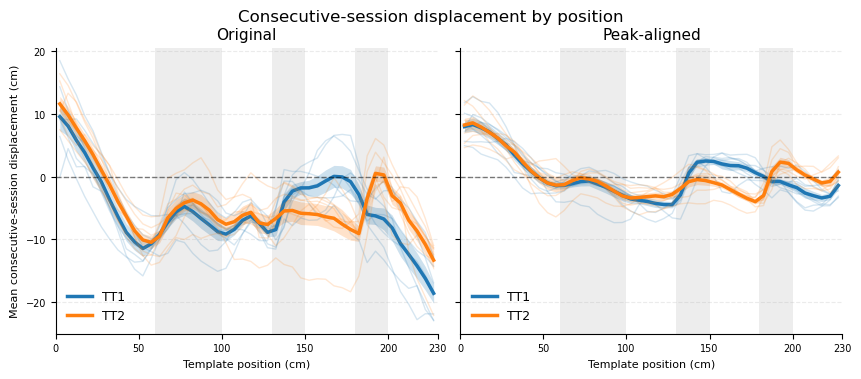

Saved PDF:
/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/consecutive_session_displacement_by_position_original_vs_peak_aligned_TT1_TT2.pdf


In [87]:
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings

save_dir = "/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper"
os.makedirs(save_dir, exist_ok=True)

colors = {
    1: "tab:blue",
    2: "tab:orange"
}

group_labels = {
    "original": "Original",
    "peak_aligned": "Peak-aligned"
}

# -------------------------------------------------------
# average across consecutive-session pairs within each animal
# for both original and peak-aligned groups
# -------------------------------------------------------

animal_mean_vector_by_group_tt = {}

for group in ["original", "peak_aligned"]:

    animal_mean_vector_by_group_tt[group] = {}

    session_shift_matrix = session_shift_consecutive_by_group_animal_tt[group]

    for trial_type in [1, 2]:

        animal_vectors = []
        animals_used = []

        for animal in animals:

            mat = session_shift_matrix[animal][trial_type]["matrix"]
            # mat shape = consecutive session pairs x spatial bins

            if mat.size == 0:
                continue

            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=RuntimeWarning)
                animal_vec = np.nanmean(mat, axis=0)

            if np.all(~np.isfinite(animal_vec)):
                continue

            animal_vectors.append(animal_vec)
            animals_used.append(animal)

        animal_vectors = np.asarray(animal_vectors)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)

            mean_vec = np.nanmean(animal_vectors, axis=0)

            if animal_vectors.shape[0] > 1:
                sem_vec = (
                    np.nanstd(animal_vectors, axis=0, ddof=1)
                    / np.sqrt(animal_vectors.shape[0])
                )
            else:
                sem_vec = np.full_like(mean_vec, np.nan)

        animal_mean_vector_by_group_tt[group][trial_type] = {
            "animal_vectors": animal_vectors,
            "mean": mean_vec,
            "sem": sem_vec,
            "animals_used": animals_used
        }


# -------------------------------------------------------
# plot both groups side by side
# -------------------------------------------------------

n_bins = animal_mean_vector_by_group_tt["original"][1]["mean"].shape[0]
x_cm = np.arange(n_bins) * bin_size + bin_size / 2

fig, axes = plt.subplots(
    1,
    2,
    figsize=(8.5, 3.5),
    constrained_layout=True,
    sharex=True,
    sharey=True
)

for ax, group in zip(axes, ["original", "peak_aligned"]):

    for trial_type in [1, 2]:

        d = animal_mean_vector_by_group_tt[group][trial_type]

        animal_vectors = d["animal_vectors"]
        mean_vec = d["mean"]
        sem_vec = d["sem"]

        for y in animal_vectors:
            ax.plot(
                x_cm,
                y,
                color=colors[trial_type],
                alpha=0.18,
                lw=1
            )

        ax.plot(
            x_cm,
            mean_vec,
            color=colors[trial_type],
            lw=2.5,
            label=f"TT{trial_type}"
        )

        ax.fill_between(
            x_cm,
            mean_vec - sem_vec,
            mean_vec + sem_vec,
            color=colors[trial_type],
            alpha=0.22,
            linewidth=0
        )

    for a, b in [(60, 100), (130, 150), (180, 200)]:
        ax.axvspan(a, b, color="k", alpha=0.07, lw=0)

    ax.axhline(
        0,
        color="k",
        ls="--",
        lw=1,
        alpha=0.5
    )

    ax.set_xlim(0, track_len)
    ax.set_xticks([0, 50, 100, 150, 200, 230])

    ax.set_xlabel("Template position (cm)")
    ax.set_title(group_labels[group], fontsize=11)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(axis="y", alpha=0.25, linestyle="--")
    ax.legend(frameon=False, fontsize=9)

axes[0].set_ylabel("Mean consecutive-session displacement (cm)")

fig.suptitle(
    "Consecutive-session displacement by position",
    fontsize=12,
    y=1.04
)

pdf_path = os.path.join(
    save_dir,
    "consecutive_session_displacement_by_position_original_vs_peak_aligned_TT1_TT2.pdf"
)

fig.savefig(
    pdf_path,
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

print(f"Saved PDF:\n{pdf_path}")